In [2]:
import os
import numpy as np
import random
from imports.qtlab_data import *
from imports.dataclass import *
from matplotlib.colors import to_rgba
from collections import defaultdict
from typing import List
try:
    from imports.simmons import simmons
except:
    from imports.physics_models_p import *

    simmons = physics_models.simmons
    # subfolders and pattern matching on the files
from matplotlib.colors import LinearSegmentedColormap
import plotting_functions as pf
pf.set_plotting_options()

## Helper Functions

In [3]:
def correct_path_format(path:str):
    """
    Paste the path you copy from windows into this function. It replace the single backslash with the double.
    Needs an r in from of the string.
    """
    lpath = path.split('\\')
    return '\\'.join(lpath)

def make_fit_df(lst_parm, vcs, lst_temp=None):
    n_vg_peak, n_fit_params, n_temp = len(vcs), len(lst_parm), len(lst_temp)
    parm_mat = np.zeros((n_temp, n_fit_params,n_vg_peak)) # np.zeros((n_fit_params, n_vg_peak))
    # print(len(lst_parm))
    # print(vcs)
    # print(parm_mat)
    for k,p in enumerate(lst_parm):
        print(p['Vc'])
        print(p['Gmax'])
        print(p['alpha'])
        print(p['T'])
        parm_mat[0,k,:] = p['Vc']
        parm_mat[1,k,:] = p['Gmax']
        parm_mat[2,k,:] = p['alpha']
        parm_mat[3,k,:] = p['T']
        # print(f'Loop number {k}\n{print(parm_mat)}')
    index = get_df_index(lst_temp, vcs)
    print(parm_mat.size)
    # print(parm_mat.T.reshape(36,6))
    # a = pd.DataFrame(parm_mat.T.reshape(36,-1), index=index, columns=['Vc', 'Gmax', 'alpha', 'T', 'crap1', 'crap2'])
    a = pd.DataFrame(parm_mat.T.reshape(-1, len(lst_parm)), index=index, columns=['Vc', 'Gmax', 'alpha', 'T', 'crap1', 'crap2', 'crap3'])
    print(a)
    return a

def get_df_index(lst_temp=None, vcs=None, multi_row_names=['temperature', 'vg_peak'], coulmns=['Vc', 'Gmax', 'alpha', 'T']):
    import pandas as pd
    if (lst_temp or vcs) == False:
        raise ValueError('Empty list arguments')
    round_temp = [round(temp, 2) for temp in lst_temp]
    a = [round_temp, vcs] # this will be used as multiindex
    return pd.MultiIndex.from_product(a, names=multi_row_names)

def extract_sd_temp(dset, resample_size=256, axes=("Vg", "T", "Vsd", "Isd", "t")):
    sd = dset.load(Stability_Diagram, axes=axes)
    sd = sd[0]
    sd["Vsd"] *= 1e-3
    temp_array = sd['T']
    temp_mean = round(sd['T'].values.mean(),2)
    sd.resample(resample_size,resample_size)
    sd.correct_offset()
    return sd, temp_mean, temp_array

def extract_zbgt(sd):
    return sd.zero_bias_gate_trace() # gatetrace is stil a Stability_Diagram Object

def plot_sd_zbgt(sd, zbgt, T):
    fig = Figure()
    # fig.add_subplot(Subplot_IVsVg(sd, title=f"sd_{round(T,2)}_K", cmap='plasma')) # plot SD
    fig.add_subplot(Subplot_GVsVg(sd, title=f"sd_{round(T,2)}_K", cmap="plasma")) # plot conductance SD 
    fig.add_subplot(Subplot_GVg(zbgt, title=f"zbgt_{round(T,2)}_K", cmap='plasma')) # plot gatetrace
    fig.visualise(f'{fig_dir}/sd_zbgt/sd_zbgt_{int(T)}_K') 
    
def extract_lever_arm(vg_peak):
    """
    Example:
    lst_alphas = [extract_lever_arm(vg) for vg in lst_gate_voltages]
    """
    lever_arm = {'peak1': 0.021, 'peak2': 0.023, 'peak3': 0.025, 'peak4': 0.028, 'peak5': 0.025, 'peak6': 0.023} # meV/V
    if -15.5 <= vg_peak <= -12:
        return lever_arm['peak1']
    elif -12 <= vg_peak <= -4:
        return lever_arm['peak2']
    elif -4 <= vg_peak <= 1.5:
        return lever_arm['peak3']
    elif 1.5 <= vg_peak <= 6:
        return lever_arm['peak4']
    elif 6 <= vg_peak <= 11:
        return lever_arm['peak5']
    elif 11 <= vg_peak <= 18:
        return lever_arm['peak6']
    else:
        raise ValueError(f'Seems impossible to associate a lever arm with the peak at gate voltage {vg_peak} V')
    
def lookup_dict_vg_peaks(T=None):
    # keys are T_K, values are list of Vg_V at which I see a peak
    vg_fit = {
          0.5: [-12.46, -7.41, 2.8, 8.27, 15.0],
          1.0: [-12.27, -6.15, 2.8, 9.71, 16.5],
          9.71: [-12.64, -7.41, 3.29, 9.05, 15.84],
          20.01: [-12.15, -5.79, 4.13, 9.83, 16.38],
          29.0: [-12.09, -5.73, 3.59, 9.41, 16.8],
          29.08: [-11.91, -5.97, 4.25, 9.89, 16.32],
          59.48: [-12.03, -6.15, 4.19, 9.11, 15.72],
          72.82: [-12.51, -6.86, -1.34, 7.85, 14.64],
          185.76: [-12.27, -6.81, 3.41, 8.45, 14.28],
          188.53: [-14.55, -8.67, 3.82, 8.75, 14.27],
          205.29: [-12.51, -7.9, 3.82, 10.67],
          238.49: [9.34, -5.26],
          # bandgap from -18.28, 6.83
          # 275.6: [-18.88, -7.05, 0.4, 7.37, 14.1], # this is the correct one
          275.6: [-15.3, -7.05, 0.4, 7.37, 14.1],
          # this one seems to have a bandgap deep extended from -14 to 11.7
          283.15: [-15.22, -5.73, 4.37, 10.56, 16.2],
          # these three have only one broad peak at Vg < 0
          294.48: [-13.12, -7.05, 2.74, 8.57, 13.38],
          294.68: [-13.66, -6.33, 2.44, 8.33, 13.26],
          294.9: [-13.48, -9.81, -1.7, 7.91, 14.04],
          # gap between -9.81 and 2.56
          295.13: [-13.12, -9.81, 2.56, 8.93, 15.18],
          # FET behaviour with, switch on around -5.73
          295.31: [-12.46, 6.11, 13.74, 17.16, -15.3],
          # 295.31: [-12.46, 6.11, 13.74, 17.16, -18.7],
          # gap between -14.26 and 7.43
          295.49: [-14.26, 7.43]
          }
    total_length_gates = 0
    for i in vg_fit.values():
        total_length_gates += len(i)
    print(total_length_gates)
    return vg_fit[T]

def fit_zbgt(sd, vc, T, vc_offset = 2.5):
    setdct = {"Vc": vc, "T": T} 
    dat2 = sd.copy().ps(**setdct)
    zbgt = extract_zbgt(dat2)
    dat2 = dat2[(dat2["Vg"] > (vc - vc_offset)) & (dat2["Vg"] < (vc + vc_offset))]  
    gMaxTemp = zbgt["Gsd"].values[(np.argmin(np.abs(zbgt["Vg"].values - vc)))] # We will take this as the initial guess for Gmax for the fitting
    # print("Max Gsd in this window: {:.3e} S".format(gMaxTemp))  # print the Gmax
    p0 = {
        "T": T,
        "Vc": vc,
        "Gmax": gMaxTemp,
        "alpha": extract_lever_arm(vc)
    }  
    bounds = [
        (T - 0.5, vc - 1, 0.001, 0.85 * extract_lever_arm(vc)),
        (T + 0.5, vc + 1, 1.001, 1.15 * extract_lever_arm(vc))] 
    params, r = dat2.fit_coulomb_peak(bounds=bounds, p0=p0) 
    print(f">>> Opimised Params for peak @ {vc} V: alpha_gate = {params['alpha']:.2f} meV/V, Gmax = {params['Gmax']:.2e} S, Peak position: {params['Vc']:.3f} Vg")  # print the optimised parameters
    params["T"] = T 
    fitGsd = physics_models.thermal_broadening(zbgt["Vg"].values, **params)  # use the optimised parameters and the gate voltage array to generate the Gsd fit values. First argument has to be Vg.
    gatetraceFit = zbgt.copy()
    gatetraceFit["Gsd"] = fitGsd

    # added these two lines
    lst_temp.append(params['T'])
    lst_parm.append(params)

    try:
        # add the fitted gate trace to the list
        gatetraceFits.append(gatetraceFit)
    except:
        pass

## Find the Data

In [133]:
# Extract the temperature column, plot and save them

def get_df_sd(sd):
    import glob
    
    data_dir = correct_path_format(r'C:\Users\oums1095\projects\gnr_set\data\5.Temperature_Dataset\copy_justSD_Aug')
    sd_files = glob.glob(data_dir + '/*IVsVg*.dat')
    col_names = ["Vg", "T", "Vsd", "Isd", "t"]
    file_number = sd.split("\\")[-1].split('_')[0]
    df = pd.read_csv(sd, delimiter='\t', sep='\t', header=20, names=col_names)
    return df

def get_temp_err(df):
    return round(df['T'].values.mean(), 4), round(df['T'].values.std(),4)

def plot_temp_during_sd_acquisition():
    import glob
    sd_files = glob.glob(data_dir + '/*IVsVg*.dat')
    plot_kwargs={'grid':False,'fontsize':10, 's':.05}
    
    for i, sd in enumerate(sd_files):
        sd = get_df_sd(sd)
        Axes = df.plot.scatter('Vg', 'T', figsize=(15,9.27), xlabel = 'Vg / V', ylabel = 'T / K', **plot_kwargs)
        plt.setp(Axes.xaxis.get_label(), 'size', 12)
        plt.setp(Axes.yaxis.get_label(), 'size', 12)
        os.chdir('C:/Users/oums1095/projects/gnr_set/figures/sd_temp_progress')
        Axes.figure.savefig(f'{file_number}_sd_temp_variation.png', dpi=300)
        
def run():
    import glob
    temps_err = []
    sd_files = glob.glob(data_dir + '/*IVsVg*.dat')
    for i, sd in enumerate(sd_files):
        df = get_df_sd(sd)
        temps_err.append(get_temp_err(df))
    
    sort = sorted(temps_err, key=lambda tup: tup[0])
    print(sort)
    
        
    
run()

[(0.0254, 0.0006), (0.4999, 0.0002), (1.0001, 0.0007), (9.7072, 0.0075), (20.0123, 0.0828), (29.0024, 0.0122), (29.0755, 0.2519), (59.4796, 0.6143), (72.819, 0.0), (185.7631, 4.5126), (188.5292, 8.7777), (205.2876, 6.7503), (238.4858, 2.393), (275.5954, 4.0491), (283.1514, 0.0934), (294.4812, 0.0718), (294.6842, 0.0824), (294.8987, 0.0709), (295.129, 0.0731), (295.3101, 0.0672), (295.4924, 0.0559)]


In [4]:
dat_dir = correct_path_format(r'C:\Users\oums1095\projects\gnr_set\data\5.Temperature_Dataset\copy_justSD_Aug')
fig_dir = correct_path_format(r"C:\Users\oums1095\projects\gnr_set\figures\/")
dset = QTLab_Dataset.find(dat_dir)
print(dset)

> Updating info timestamp in dataset.
exp	type	device	filename	id	timestamp	axes
Ale01	IVsVg	r31	C:/Users/oums1095/projects/gnr_set/data/5.Temperature_Dataset/copy_justSD_Aug/012748_Ale01_IVsVg_r31.dat	0	1566610068	['Vg_V', 'MC_Temp_K', 'Vsd_mV', 'Is_A', 'TimeStamp_s']
Ale01	IVsVg	r31	C:/Users/oums1095/projects/gnr_set/data/5.Temperature_Dataset/copy_justSD_Aug/020617_Ale01_IVsVg_r31.dat	1	1566180377	['Vg_V', 'MC_Temp_K', 'Vsd_mV', 'Is_A', 'TimeStamp_s']
Ale01	IVsVg	r31	C:/Users/oums1095/projects/gnr_set/data/5.Temperature_Dataset/copy_justSD_Aug/022320_Ale01_IVsVg_r31.dat	2	1566354200	['Vg_V', 'MC_Temp_K', 'Vsd_mV', 'Is_A', 'TimeStamp_s']
Ale01	IVsVg	r31	C:/Users/oums1095/projects/gnr_set/data/5.Temperature_Dataset/copy_justSD_Aug/053623_Ale01_IVsVg_r31.dat	3	1565588183	['Vg_V', 'MC_Temp_K', 'Vsd_mV', 'Is_A', 'TimeStamp_s']
Ale01	IVsVg	r31	C:/Users/oums1095/projects/gnr_set/data/5.Temperature_Dataset/copy_justSD_Aug/084328_Ale01_IVsVg_r31.dat	4	1563353008	['Vg_V', 'MC_Temp_K', 'Vsd_mV

data_dir = r"C:\\Users\\oums1095\\Nexus365\\Simen Sopp - OxNanoSpin Team Folder\\Transport\\Ale01_r31\\5.Temperature_Dataset\copy_justSD_Aug"
fig_dir = r"C:\\Users\\oums1095\\projects\\gnr_set\\figures"
os.chdir(data_dir)## Find the Data

## Load SD and ZBGT Data

In [4]:
# load the data, in this case I load just one by indexing the dataset
lst_sd = []
lst_T =  []
lst_zbgt = []
lst_gt1mv = []
lst_gt2mv = []
lst_gt10mv = []
def plot_gt(gt, T, title='gt_1mv', path=r"C:\Users\oums1095\projects\gnr_set\figures"):
    fig_dir = correct_path_format(path)
    fig = Figure()
    fig.add_subplot(Subplot_GVg(gt, title=f'{title}_{int(T)}_K'))
    fig.visualise(f'{fig_dir}/{title}/{title}_{int(T)}_K')

for i in dset:
    sd, T = extract_sd_temp(i, resample_size=1024)
    zbgt = extract_zbgt(sd)
    gt_1mv = sd.gatetrace(1e-3) # vs here in mv, this bc the extract_sd_temp function converts everything in mv
    gt_2mv = sd.gatetrace(1e-2) 
    gt_10mv = sd.gatetrace(1e-2)
    lst_sd.append(sd)
    lst_T.append(T)
    lst_zbgt.append(zbgt)
    # lst_gt1mv.append(gt_1mv)
    # lst_gt2mv.append(gt_2mv)
    # lst_gt10mv.append(gt_10mv)
    # plot_gt(gt_1mv, T)
    # plot_gt(gt_2mv, T, title='gt_2mv')
    # plot_gt(gt_10mv, T, title='gt_10mv')        

Loading ... C:/Users/oums1095/projects/gnr_set/data/5.Temperature_Dataset/copy_justSD_Aug/012748_Ale01_IVsVg_r31.dat
Loading ... C:/Users/oums1095/projects/gnr_set/data/5.Temperature_Dataset/copy_justSD_Aug/020617_Ale01_IVsVg_r31.dat
Loading ... C:/Users/oums1095/projects/gnr_set/data/5.Temperature_Dataset/copy_justSD_Aug/022320_Ale01_IVsVg_r31.dat
Loading ... C:/Users/oums1095/projects/gnr_set/data/5.Temperature_Dataset/copy_justSD_Aug/053623_Ale01_IVsVg_r31.dat
Loading ... C:/Users/oums1095/projects/gnr_set/data/5.Temperature_Dataset/copy_justSD_Aug/084328_Ale01_IVsVg_r31.dat
Loading ... C:/Users/oums1095/projects/gnr_set/data/5.Temperature_Dataset/copy_justSD_Aug/103850_Ale01_IVsVg_r31.dat
Loading ... C:/Users/oums1095/projects/gnr_set/data/5.Temperature_Dataset/copy_justSD_Aug/111221_Ale01_IVsVg_r31.dat
Loading ... C:/Users/oums1095/projects/gnr_set/data/5.Temperature_Dataset/copy_justSD_Aug/113421_Ale01_IVsVg_r31.dat
Loading ... C:/Users/oums1095/projects/gnr_set/data/5.Temperatur

In [11]:
dct = {}
sort_temp = sorted(lst_T)
sort_zbgt = [x for _,x in sorted(zip(lst_T, lst_zbgt))]
for i, zbgt in enumerate(sort_zbgt):
    if i <= 0:
        vg = zbgt['Vg'].values
        dct.update({'Vg': vg})
    gsd = zbgt['Gsd'].values
    dct.update({f'Gsd_{sort_temp[i]}_K': gsd})
print(dct)
df = pd.DataFrame(dct)
df.to_csv('zbgt_1024sampled_temp.csv')

{'Vg': array([-20.        , -19.96089932, -19.92179863, ...,  19.92179863,
        19.96089932,  20.        ]), 'Gsd_0.03_K': array([-2.94560404e-12, -6.92358112e-12, -2.89321683e-12, ...,
        3.07390564e-12,  8.54287911e-12,  1.09853150e-11]), 'Gsd_0.5_K': array([ 5.86297545e-12,  3.38233140e-11,  2.17987247e-11, ...,
        2.58704968e-11,  5.68216116e-11, -1.48539377e-10]), 'Gsd_1.0_K': array([-4.06994643e-10,  8.49362886e-12, -1.31230267e-10, ...,
       -5.53127346e-11,  4.72363212e-11,  9.72356755e-11]), 'Gsd_9.71_K': array([-6.74486860e-11, -1.54993983e-11, -1.63515217e-10, ...,
        7.54943572e-11,  1.21480914e-10, -1.21918206e-10]), 'Gsd_20.01_K': array([ 3.25576140e-10,  3.06618872e-11,  1.67802185e-11, ...,
       -2.55731132e-11,  1.34487685e-11,  1.53949376e-11]), 'Gsd_29.0_K': array([-7.83907110e-11,  9.29085549e-11,  1.30735883e-11, ...,
        6.00696185e-11, -1.74973272e-11,  6.61233210e-11]), 'Gsd_29.08_K': array([-1.75943847e-10, -1.48189920e-11,  2.72877747

In [ ]:
# Plot sd and zbgt with the temperature label
for sd, zbgt, temp in zip(lst_sd, lst_zbgt, lst_T):
    plot_sd_zbgt(sd, zbgt, temp)

## Data Pre-processing

### Sort SD, GT and ZBGT from Low to High Temperature

In [29]:
sort_temp = sorted(lst_T)
sort_sd = [x for _,x in sorted(zip(lst_T, lst_sd))]
sort_zbgt = [x for _,x in sorted(zip(lst_T, lst_zbgt))]
sort_gt1mv = [x for _, x in sorted(zip(lst_T,lst_gt1mv))]
sort_gt2mv = [x for _, x in sorted(zip(lst_T,lst_gt2mv))]
sort_gt10mv = [x for _, x in sorted(zip(lst_T,lst_gt10mv))]

In [30]:
# resample the sd and the traces
sd_resampled     = [i.resample(512, 512) for i in sort_sd]
zbgt_resampled   = [i.resample(512, 512) for i in sort_zbgt]
gt1mv_resampled  = [i.resample(512, 512) for i in sort_gt1mv]
gt2mv_resampled  = [i.resample(512, 512) for i in sort_gt2mv]
gt10mv_resampled = [i.resample(512, 512) for i in sort_gt10mv]

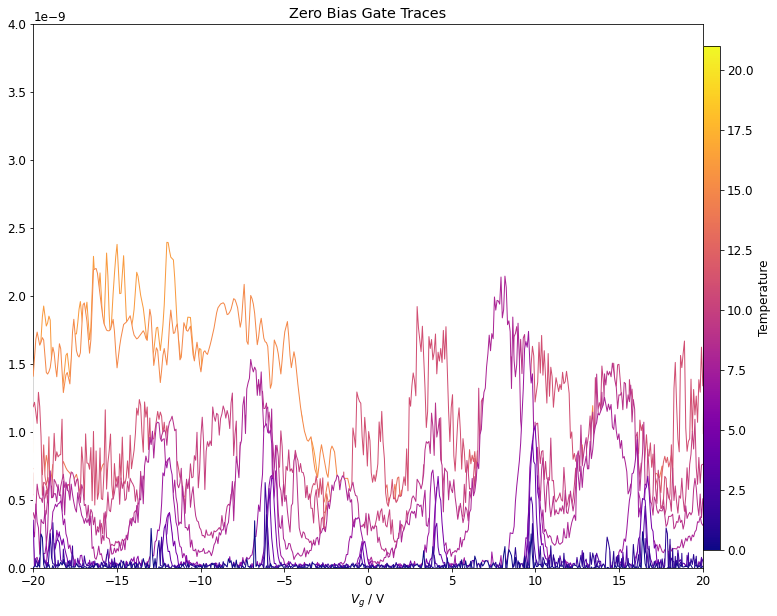

In [44]:
cmap    = mpl.cm.get_cmap('plasma')
norm    = mpl.colors.Normalize(vmin=0, vmax=len(sort_temp))
fig, ax = plt.subplots(figsize=(12,10))

for idx,i in enumerate(sort_zbgt):
    z_ind=len(sort_temp)-idx ## to ensure each plot is "behind" the previous plot
    
    xs=i['Vg'].values
    ys=i['Gsd'].values

    ## note that I am using both .plot() and .fill_between(.. edgecolor="None" ..) 
    #  in order to circumvent showing the "edges" of the fill_between 
    ax.plot(xs,ys,color=cmap(norm(idx)),linewidth=1,zorder=z_ind)
    ## try alpha=0.05 below for some "light shading"
    ax.fill_between(xs,ys,-0.5,facecolor="w",alpha=1, edgecolor="None",zorder=z_ind)

ax.set_title('Zero Bias Gate Traces')
ax.set_xlim(-20,20)
ax.set_ylim(0,4e-9)
ax.set_xlabel('$V_g$ / V')
cbax = fig.add_axes([0.9, 0.15, 0.02, 0.7]) # x-position, y-position, x-width, y-height
cb1 = mpl.colorbar.ColorbarBase(cbax, cmap=cmap, norm=norm, orientation='vertical')
cb1.set_label('Temperature')

In [222]:
# Select peaks based on vg intervals
pk1_zbgt = [zbgt[(zbgt['Vg'] > -19) & (zbgt['Vg'] < -15)] for zbgt in zbgt_resampled]
pk2_zbgt = [zbgt[(zbgt['Vg'] > -15) & (zbgt['Vg'] < -10)] for zbgt in zbgt_resampled]
pk3_zbgt = [zbgt[(zbgt['Vg'] > -10) & (zbgt['Vg'] < -4)]  for zbgt in zbgt_resampled]
pk4_zbgt = [zbgt[(zbgt['Vg'] > -4)  & (zbgt['Vg'] < 1.7)] for zbgt in zbgt_resampled]
pk5_zbgt = [zbgt[(zbgt['Vg'] > 1.7) & (zbgt['Vg'] < 6.2)] for zbgt in zbgt_resampled]
pk6_zbgt = [zbgt[(zbgt['Vg'] > 6.2) & (zbgt['Vg'] < 12)]  for zbgt in zbgt_resampled]
pk7_zbgt = [zbgt[(zbgt['Vg'] > 13)  & (zbgt['Vg'] < 18.5)]  for zbgt in zbgt_resampled]
if all_peaks_zbgt == None:
    all_peaks_zbgt = []
    all_peaks_zbgt.append(pk1_zbgt)
    all_peaks_zbgt.append(pk2_zbgt)
    all_peaks_zbgt.append(pk3_zbgt)
    all_peaks_zbgt.append(pk4_zbgt)
    all_peaks_zbgt.append(pk5_zbgt)
    all_peaks_zbgt.append(pk6_zbgt)
    all_peaks_zbgt.append(pk7_zbgt)
else:
    del all_peaks_zbgt
    all_peaks_zbgt = []
    all_peaks_zbgt.append(pk1_zbgt)
    all_peaks_zbgt.append(pk2_zbgt)
    all_peaks_zbgt.append(pk3_zbgt)
    all_peaks_zbgt.append(pk4_zbgt)
    all_peaks_zbgt.append(pk5_zbgt)
    all_peaks_zbgt.append(pk6_zbgt)
    all_peaks_zbgt.append(pk7_zbgt)
interval = np.linspace(0, 1, len(pk1_zbgt))
colors = [mpl.cm.coolwarm(x) for x in interval]

In [10]:
def peaks_progr_temp(peaks_zbgt: List, save_csv = False):
    for n, zbgt in enumerate(peaks_zbgt):
        dct = {}
        for i in range(len(zbgt)):
            x = zbgt[i]['Vg'].values
            y = zbgt[i]['Gsd'].values
            if i < 1:
                dct.update({'vg_V' : x})
            dct.update({f'pk_{n+1}_T_{sort_temp[i]}': y}) 
        df = pd.DataFrame(dct)
        if save_csv == True:
            df.to_csv(f'{fig_dir}pk{n+1}_temp.csv', )
        #return df
peaks_progr_temp(all_peaks_zbgt, save_csv=True)

NameError: name 'all_peaks_zbgt' is not defined

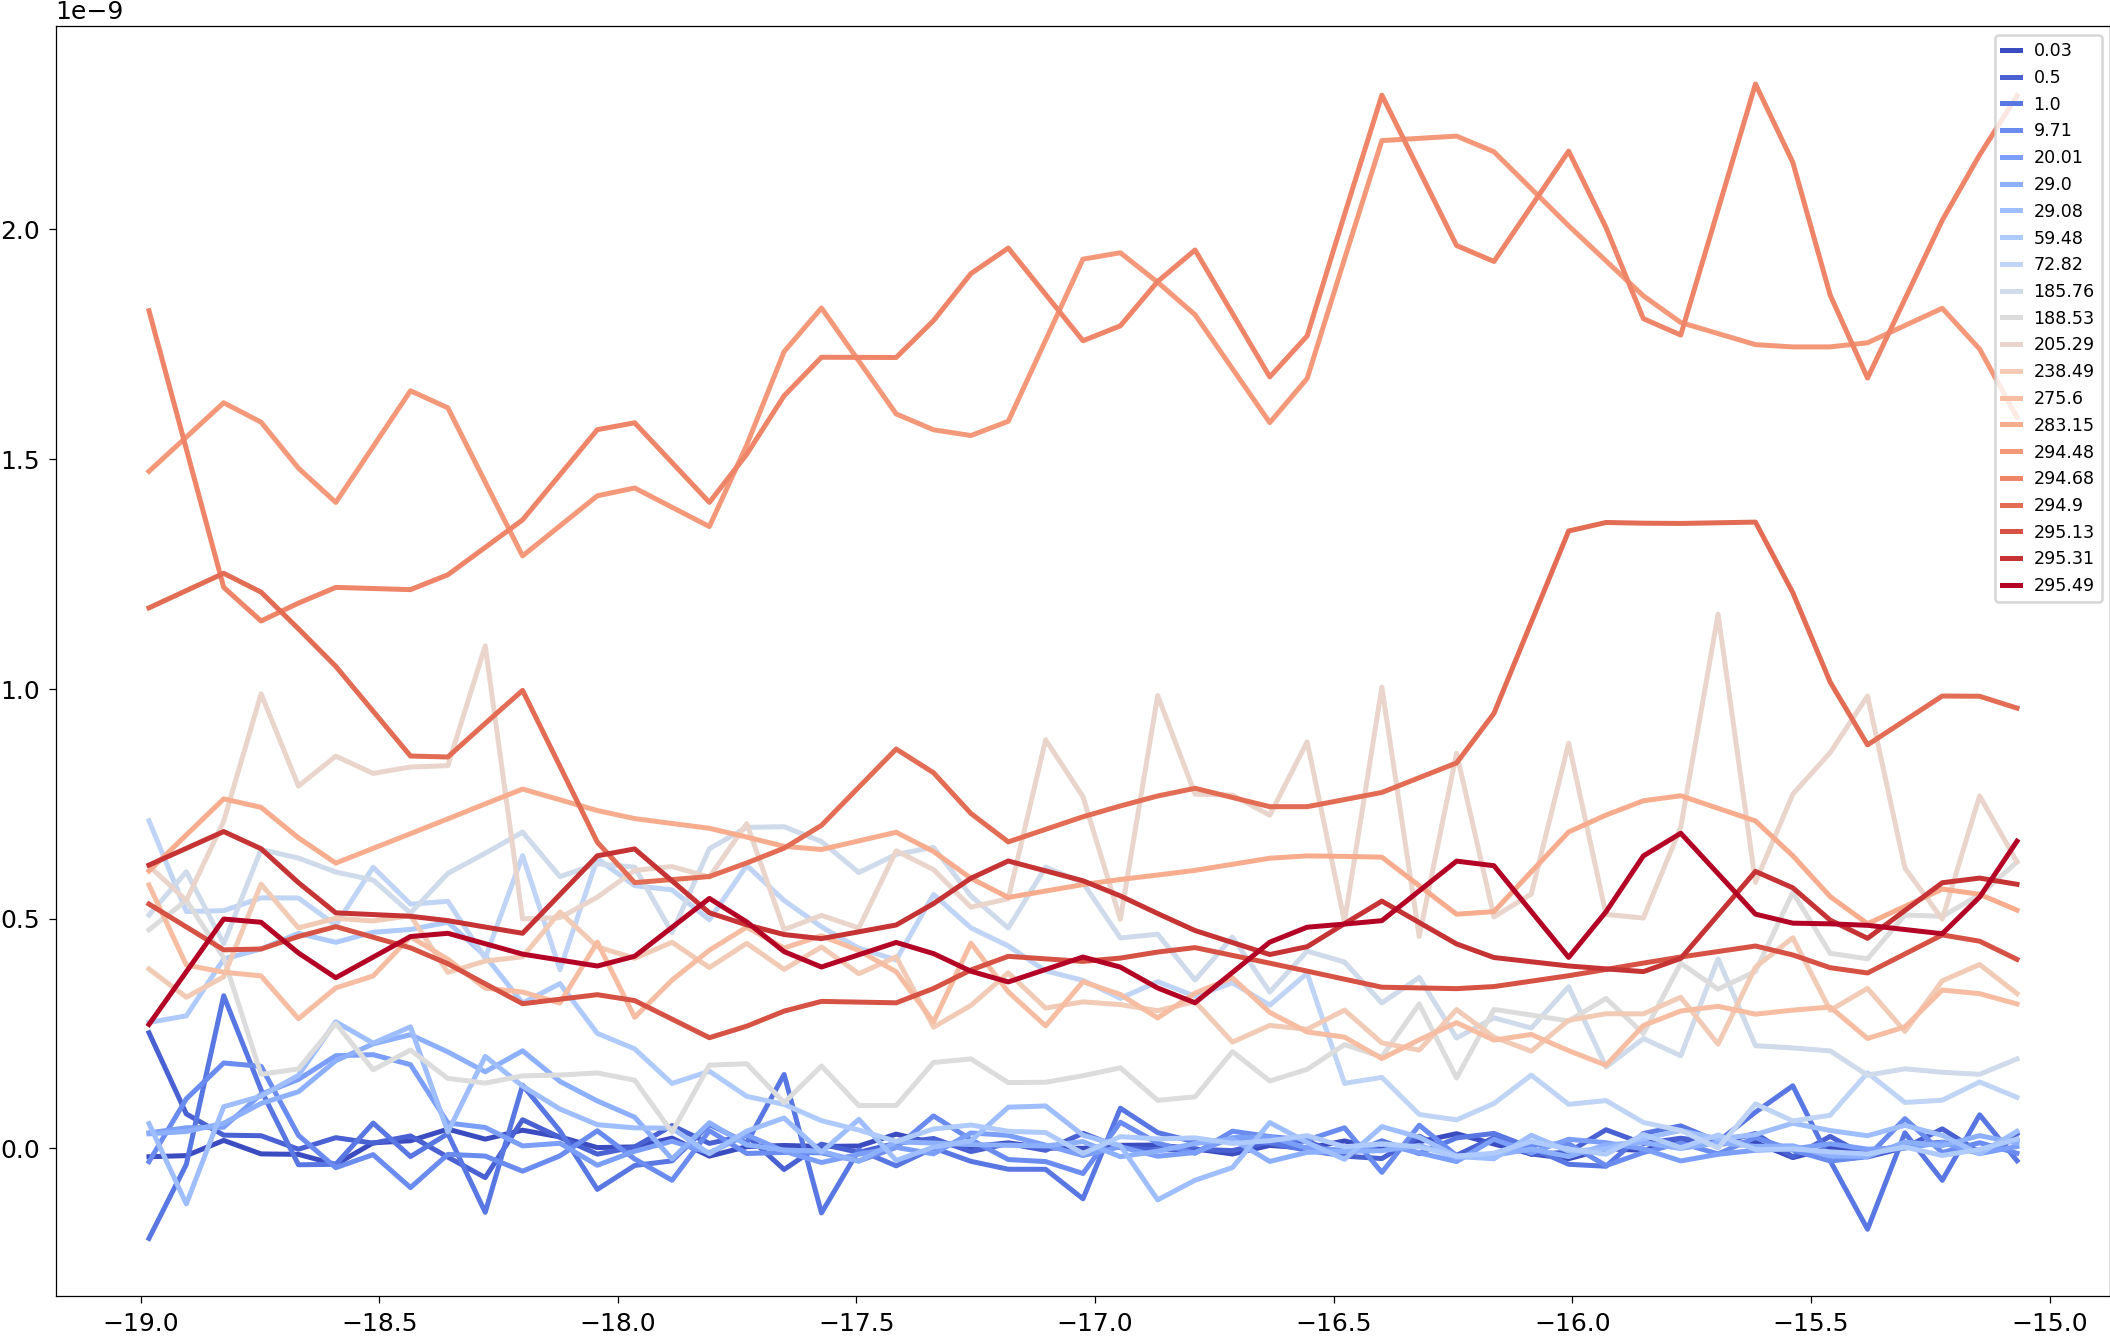

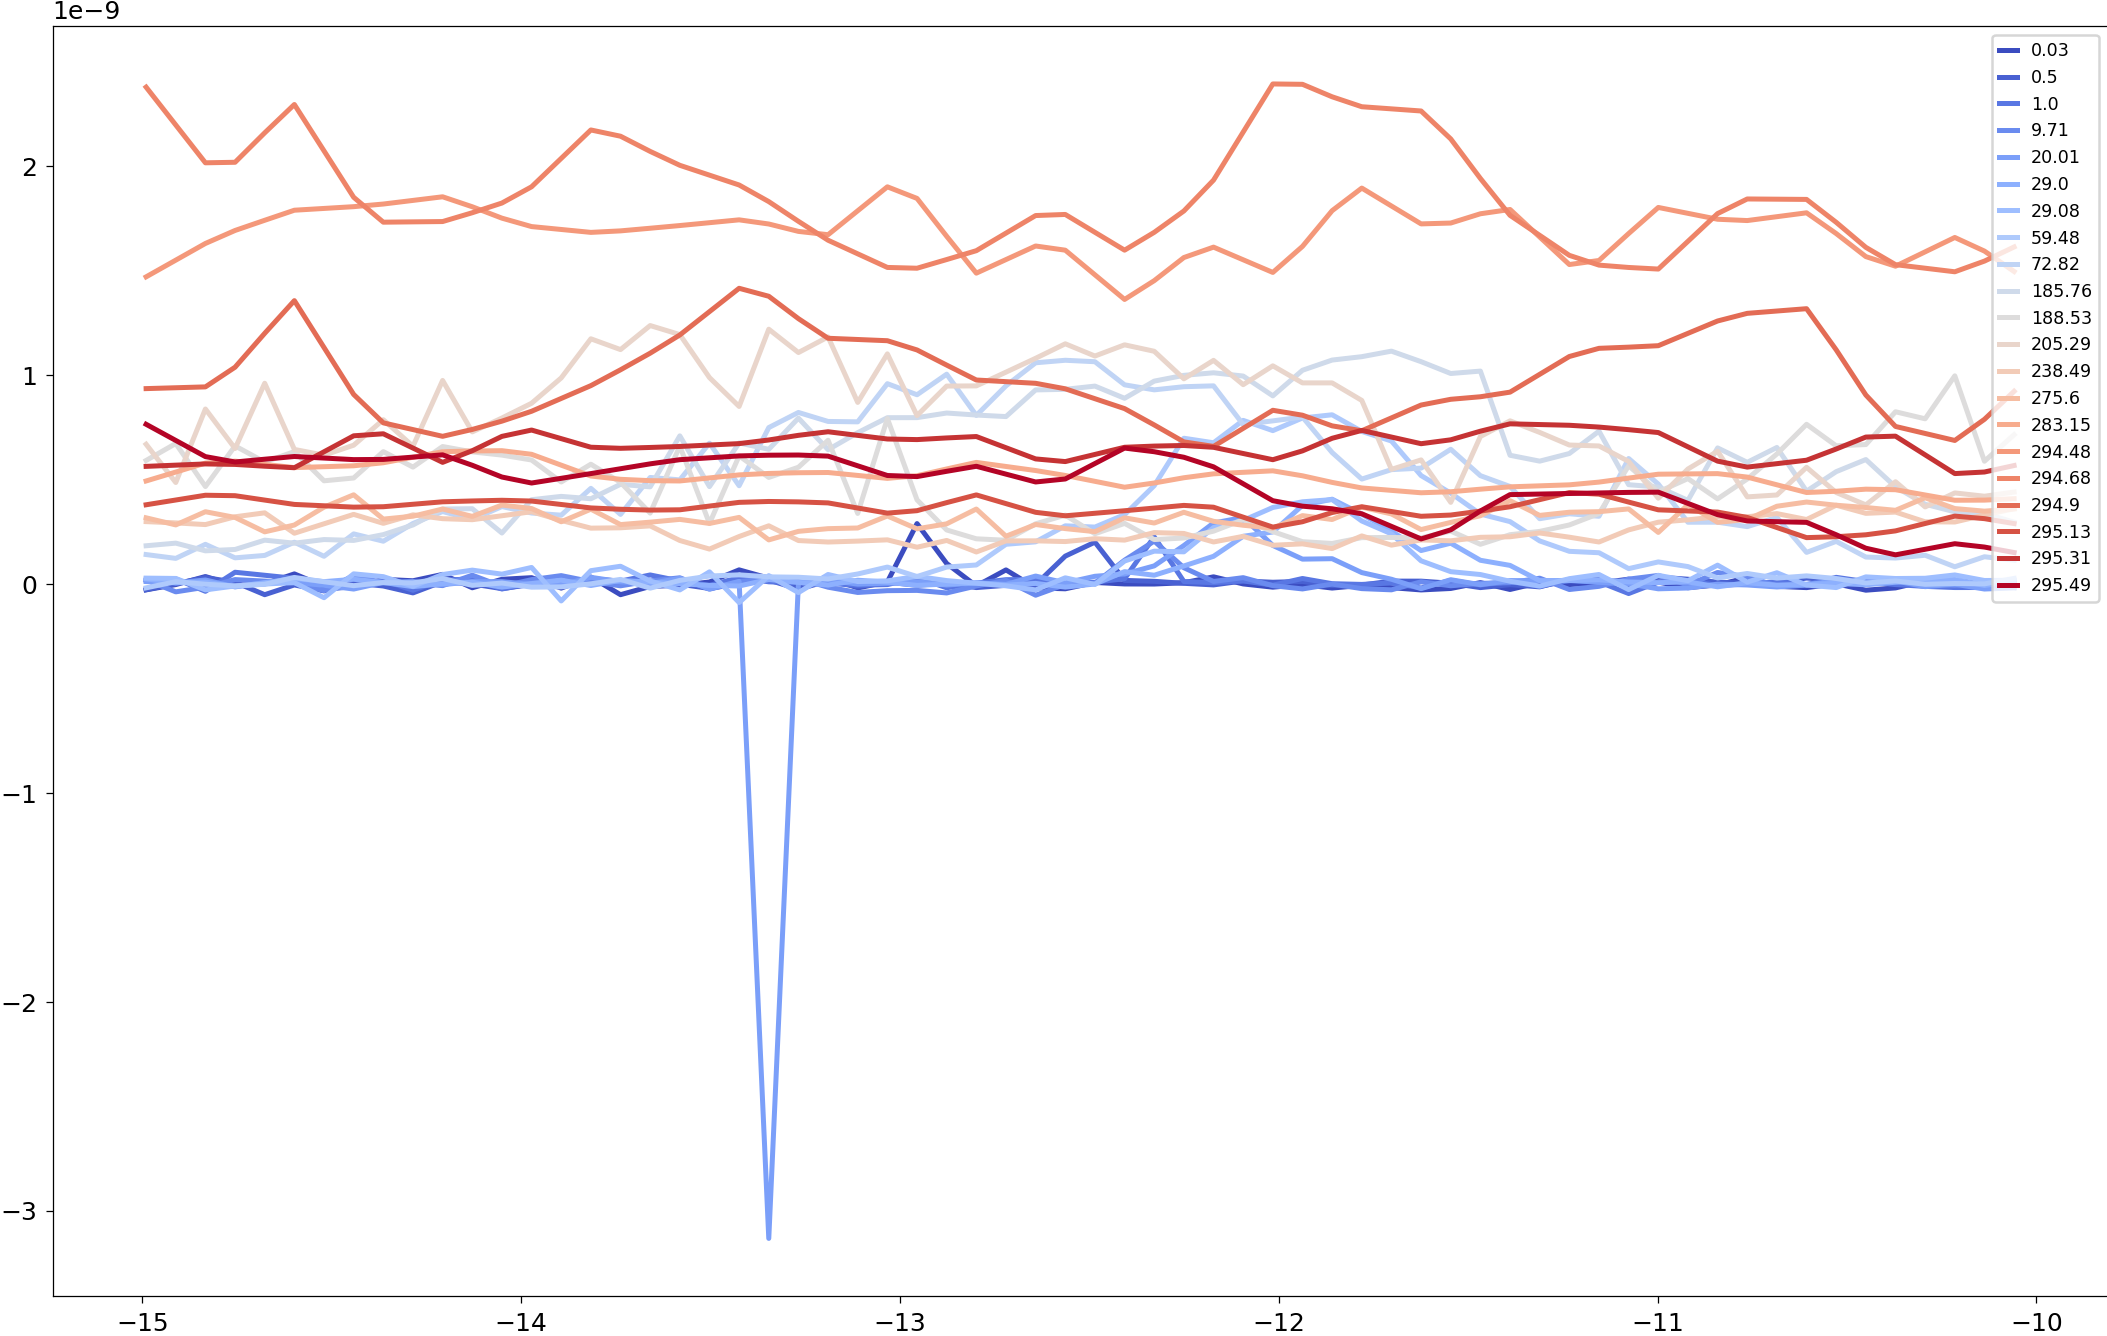

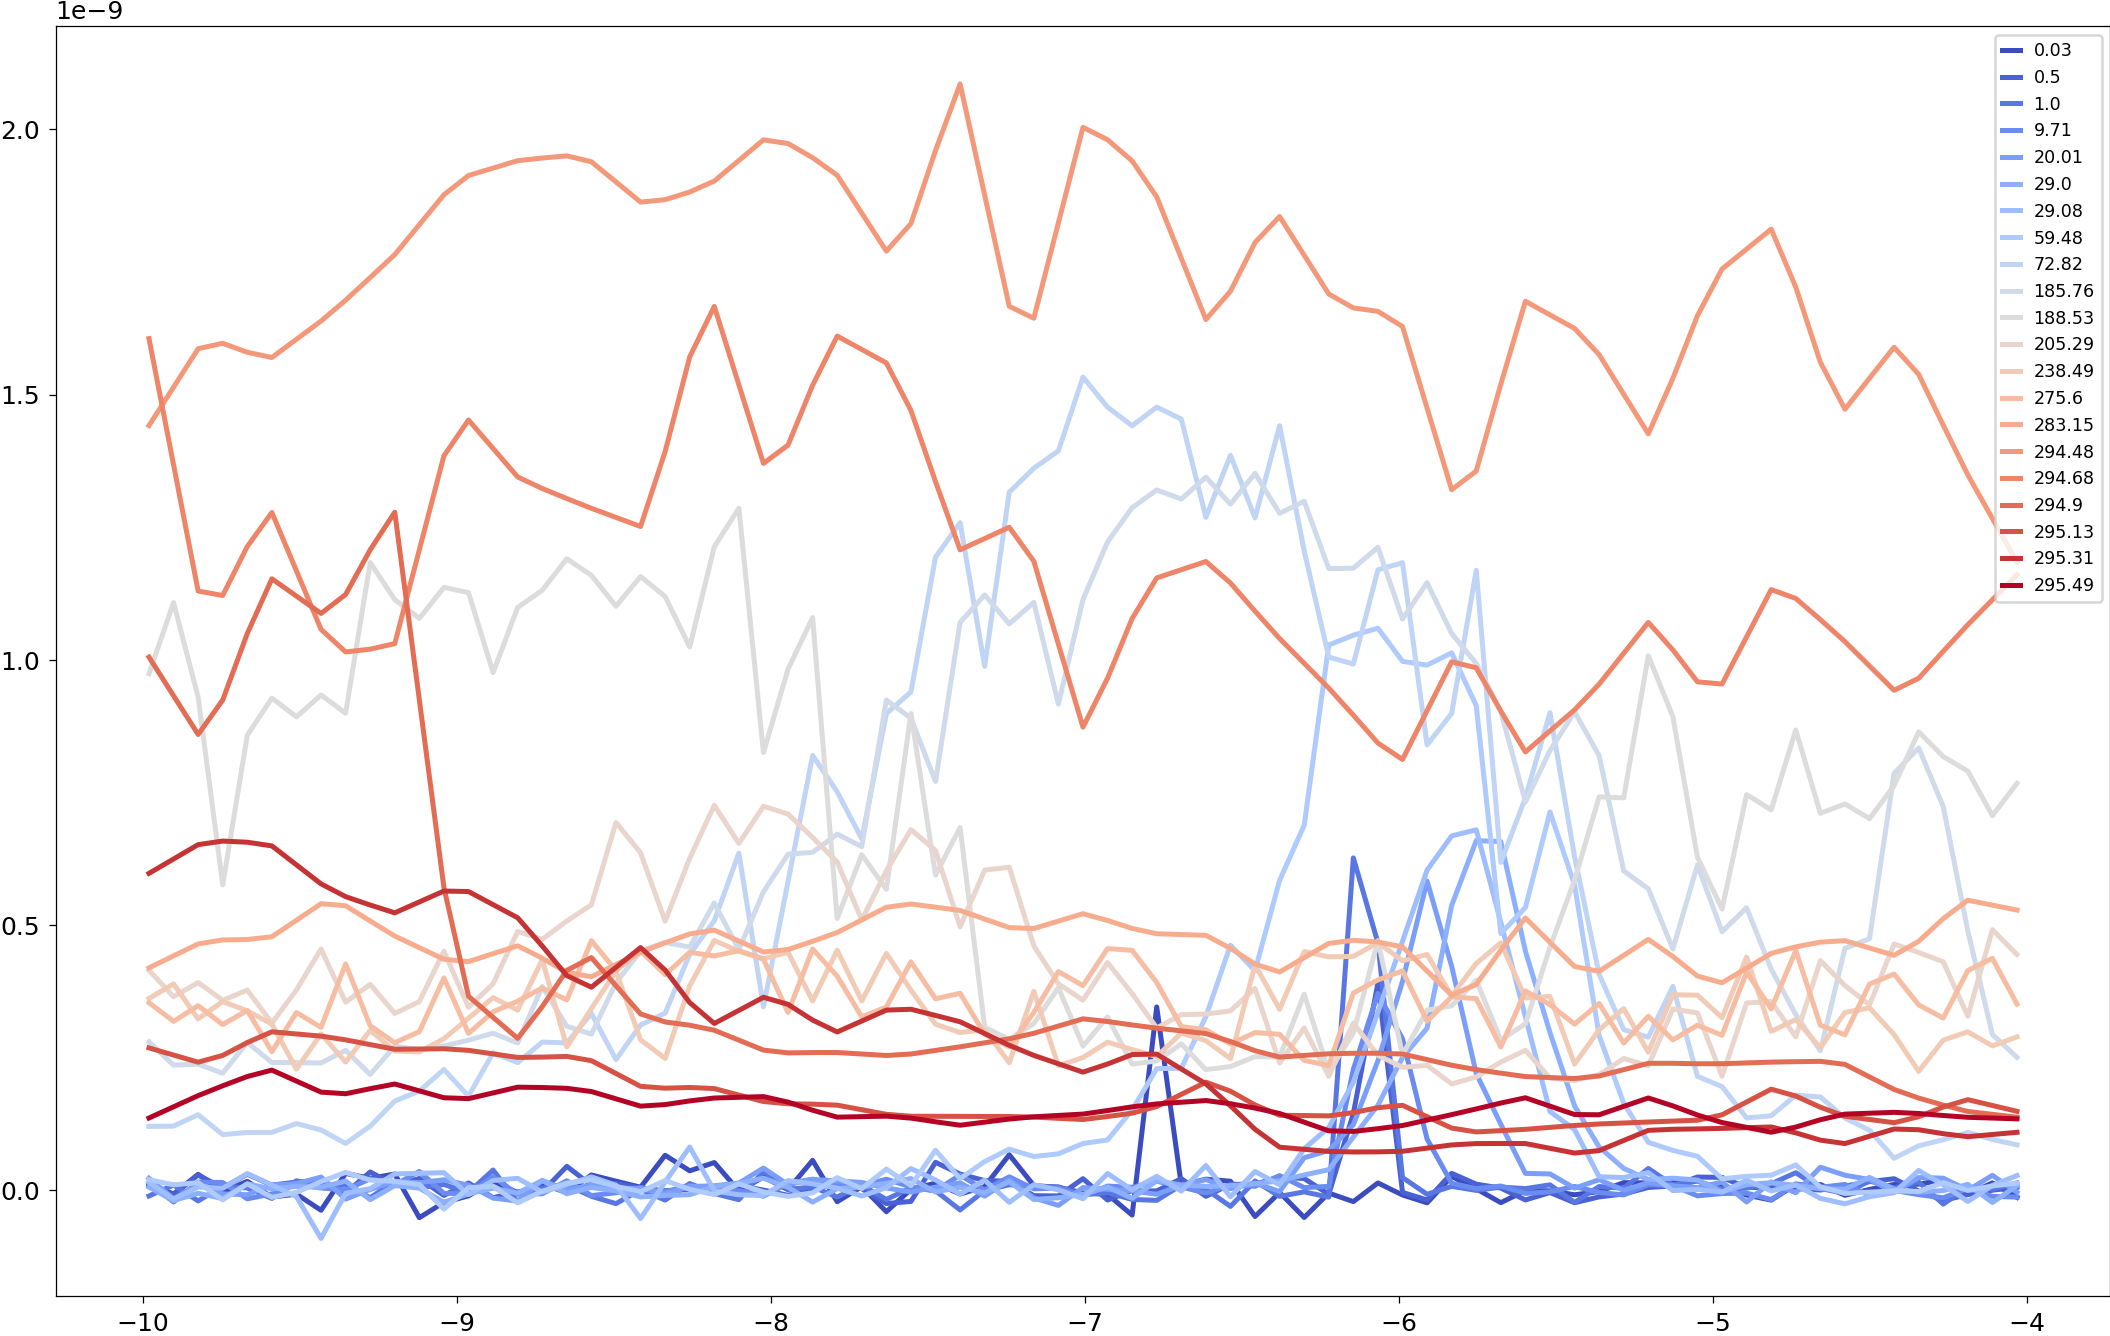

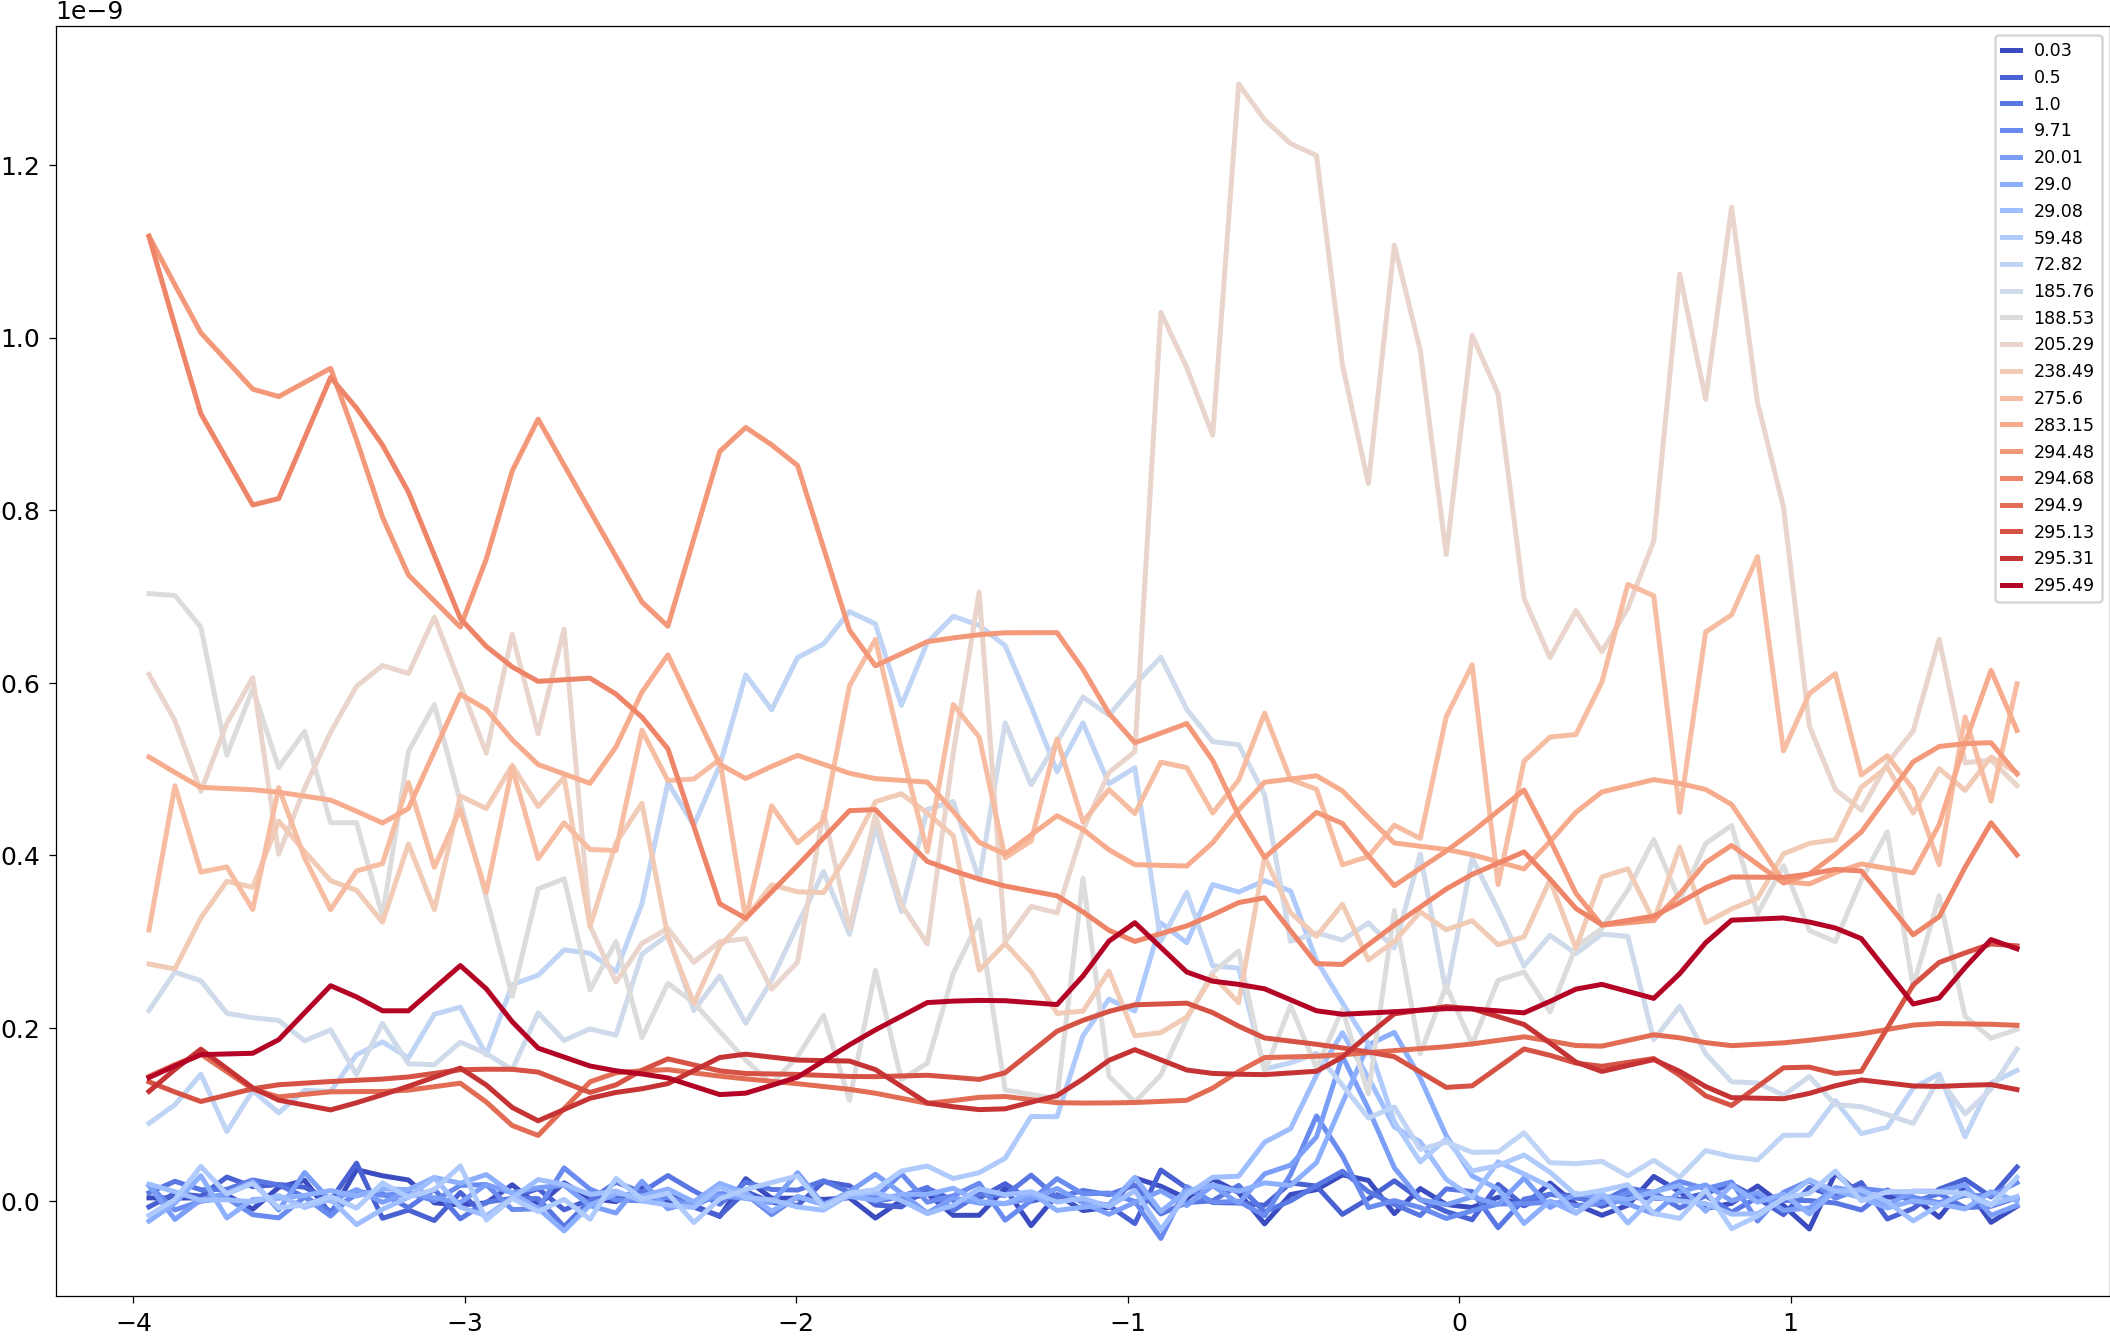

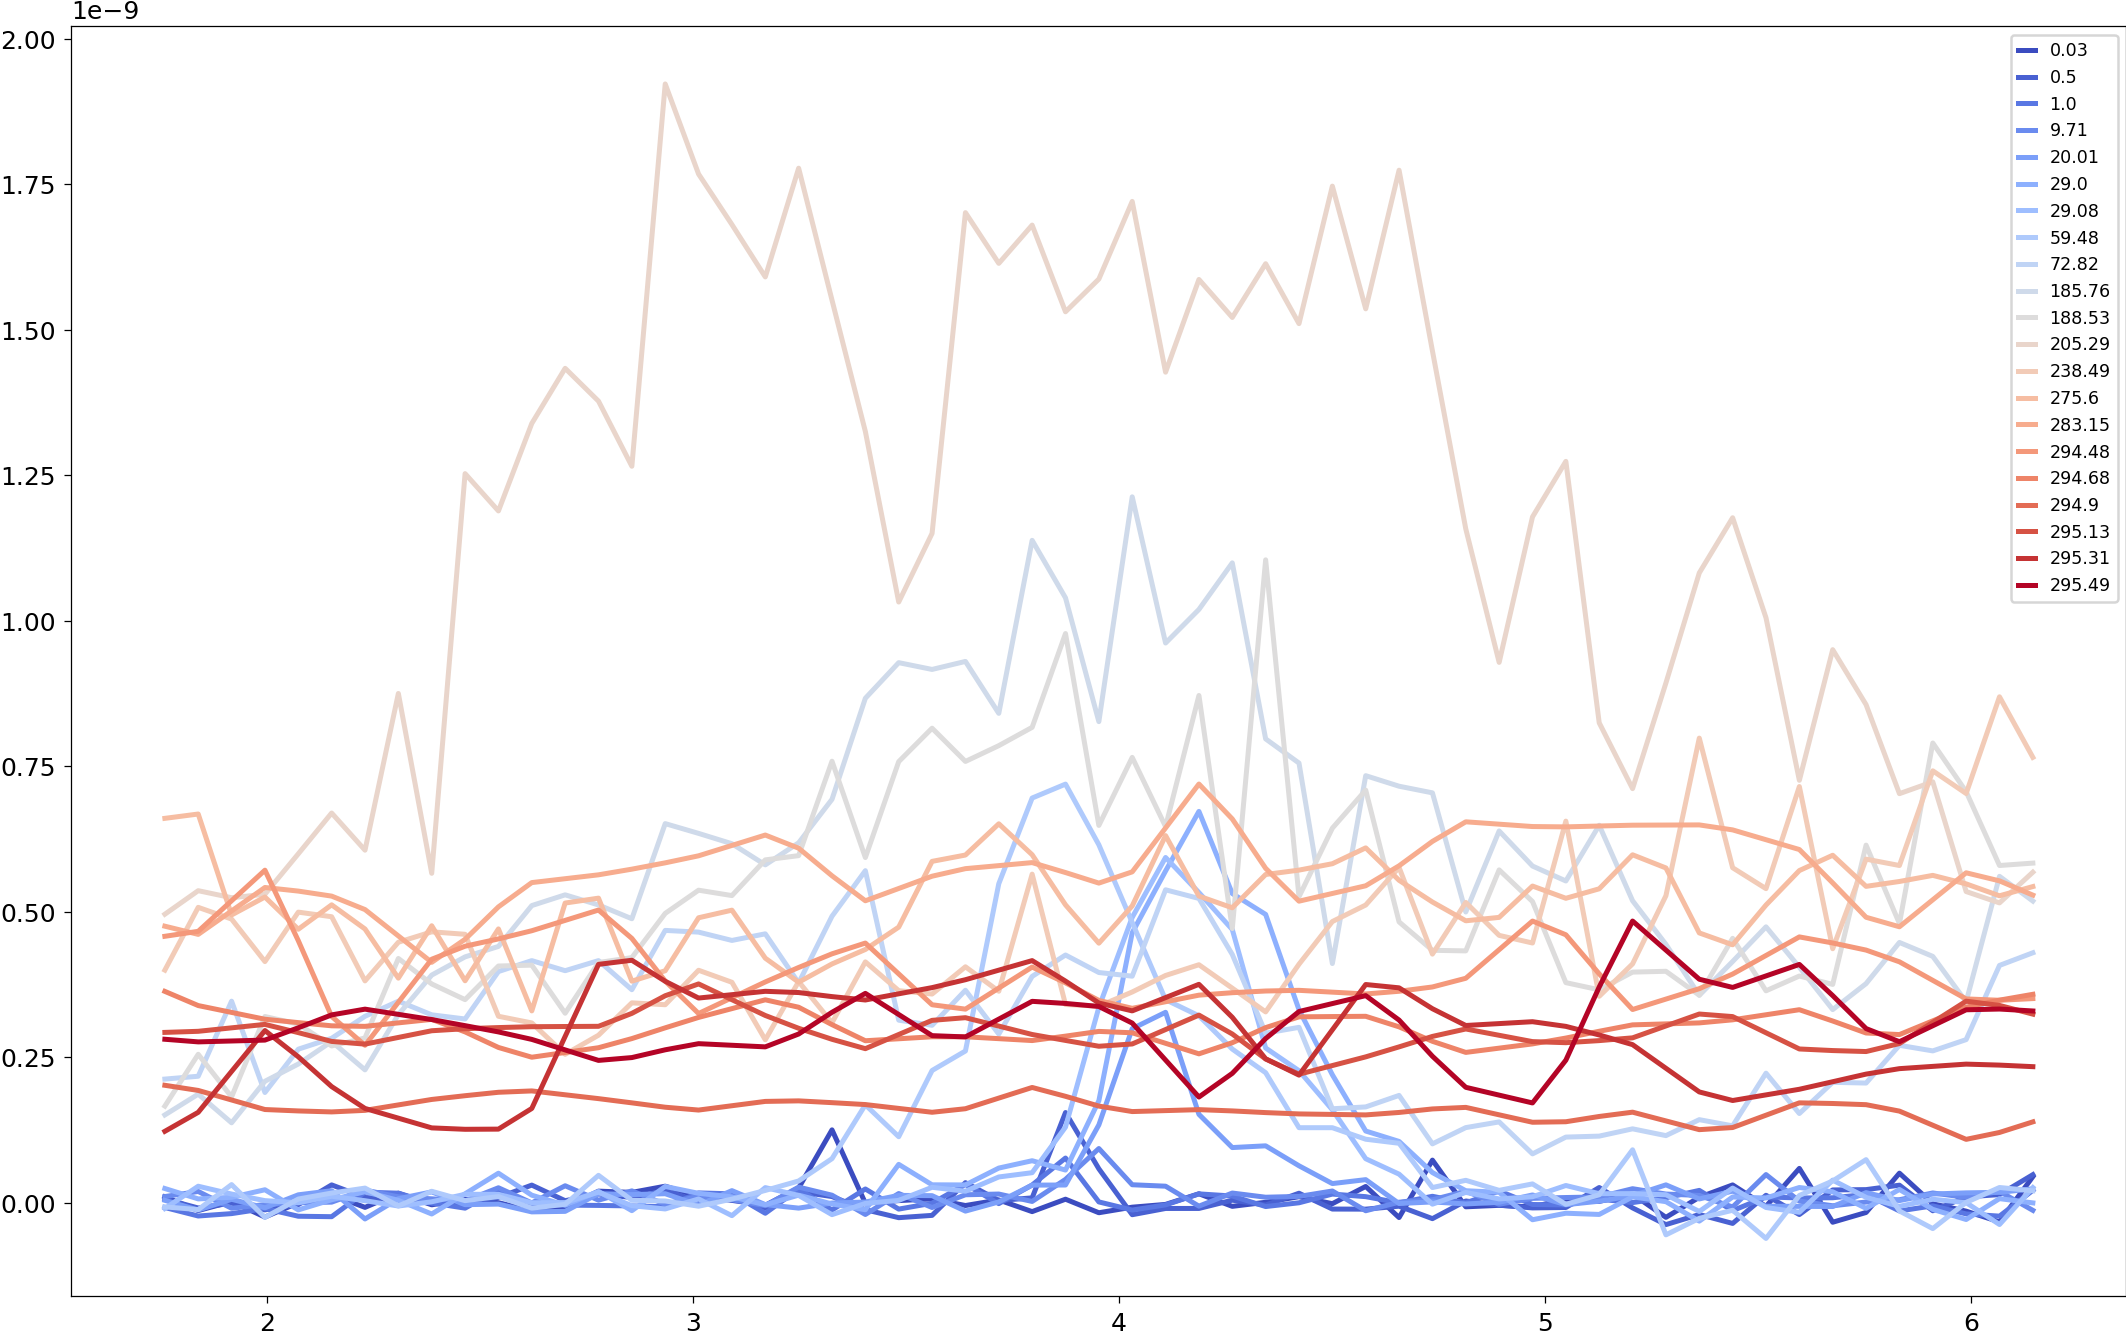

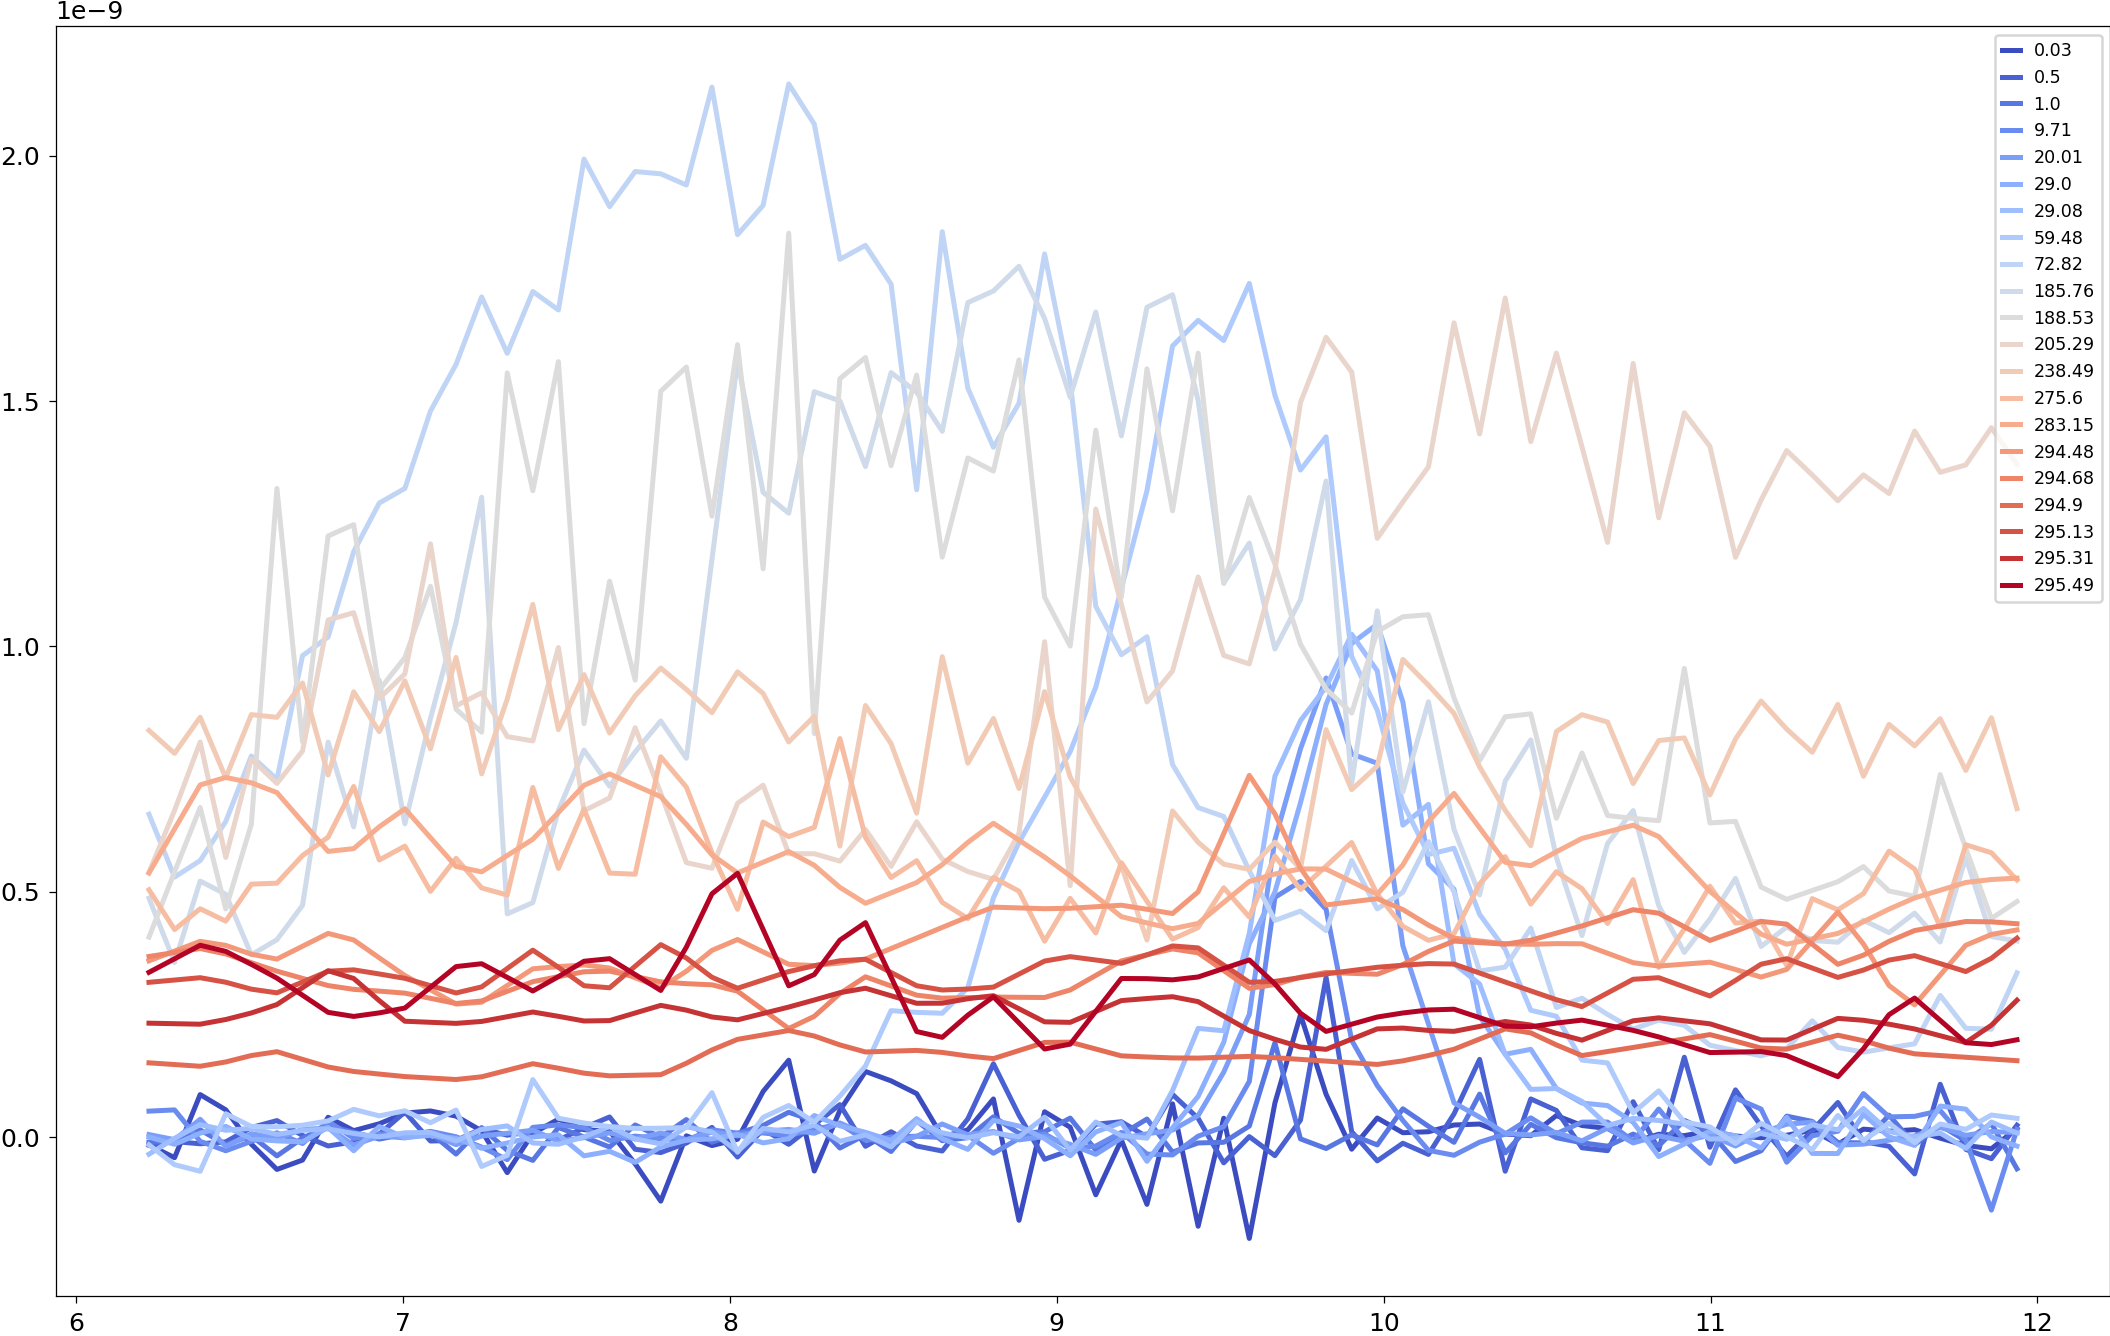

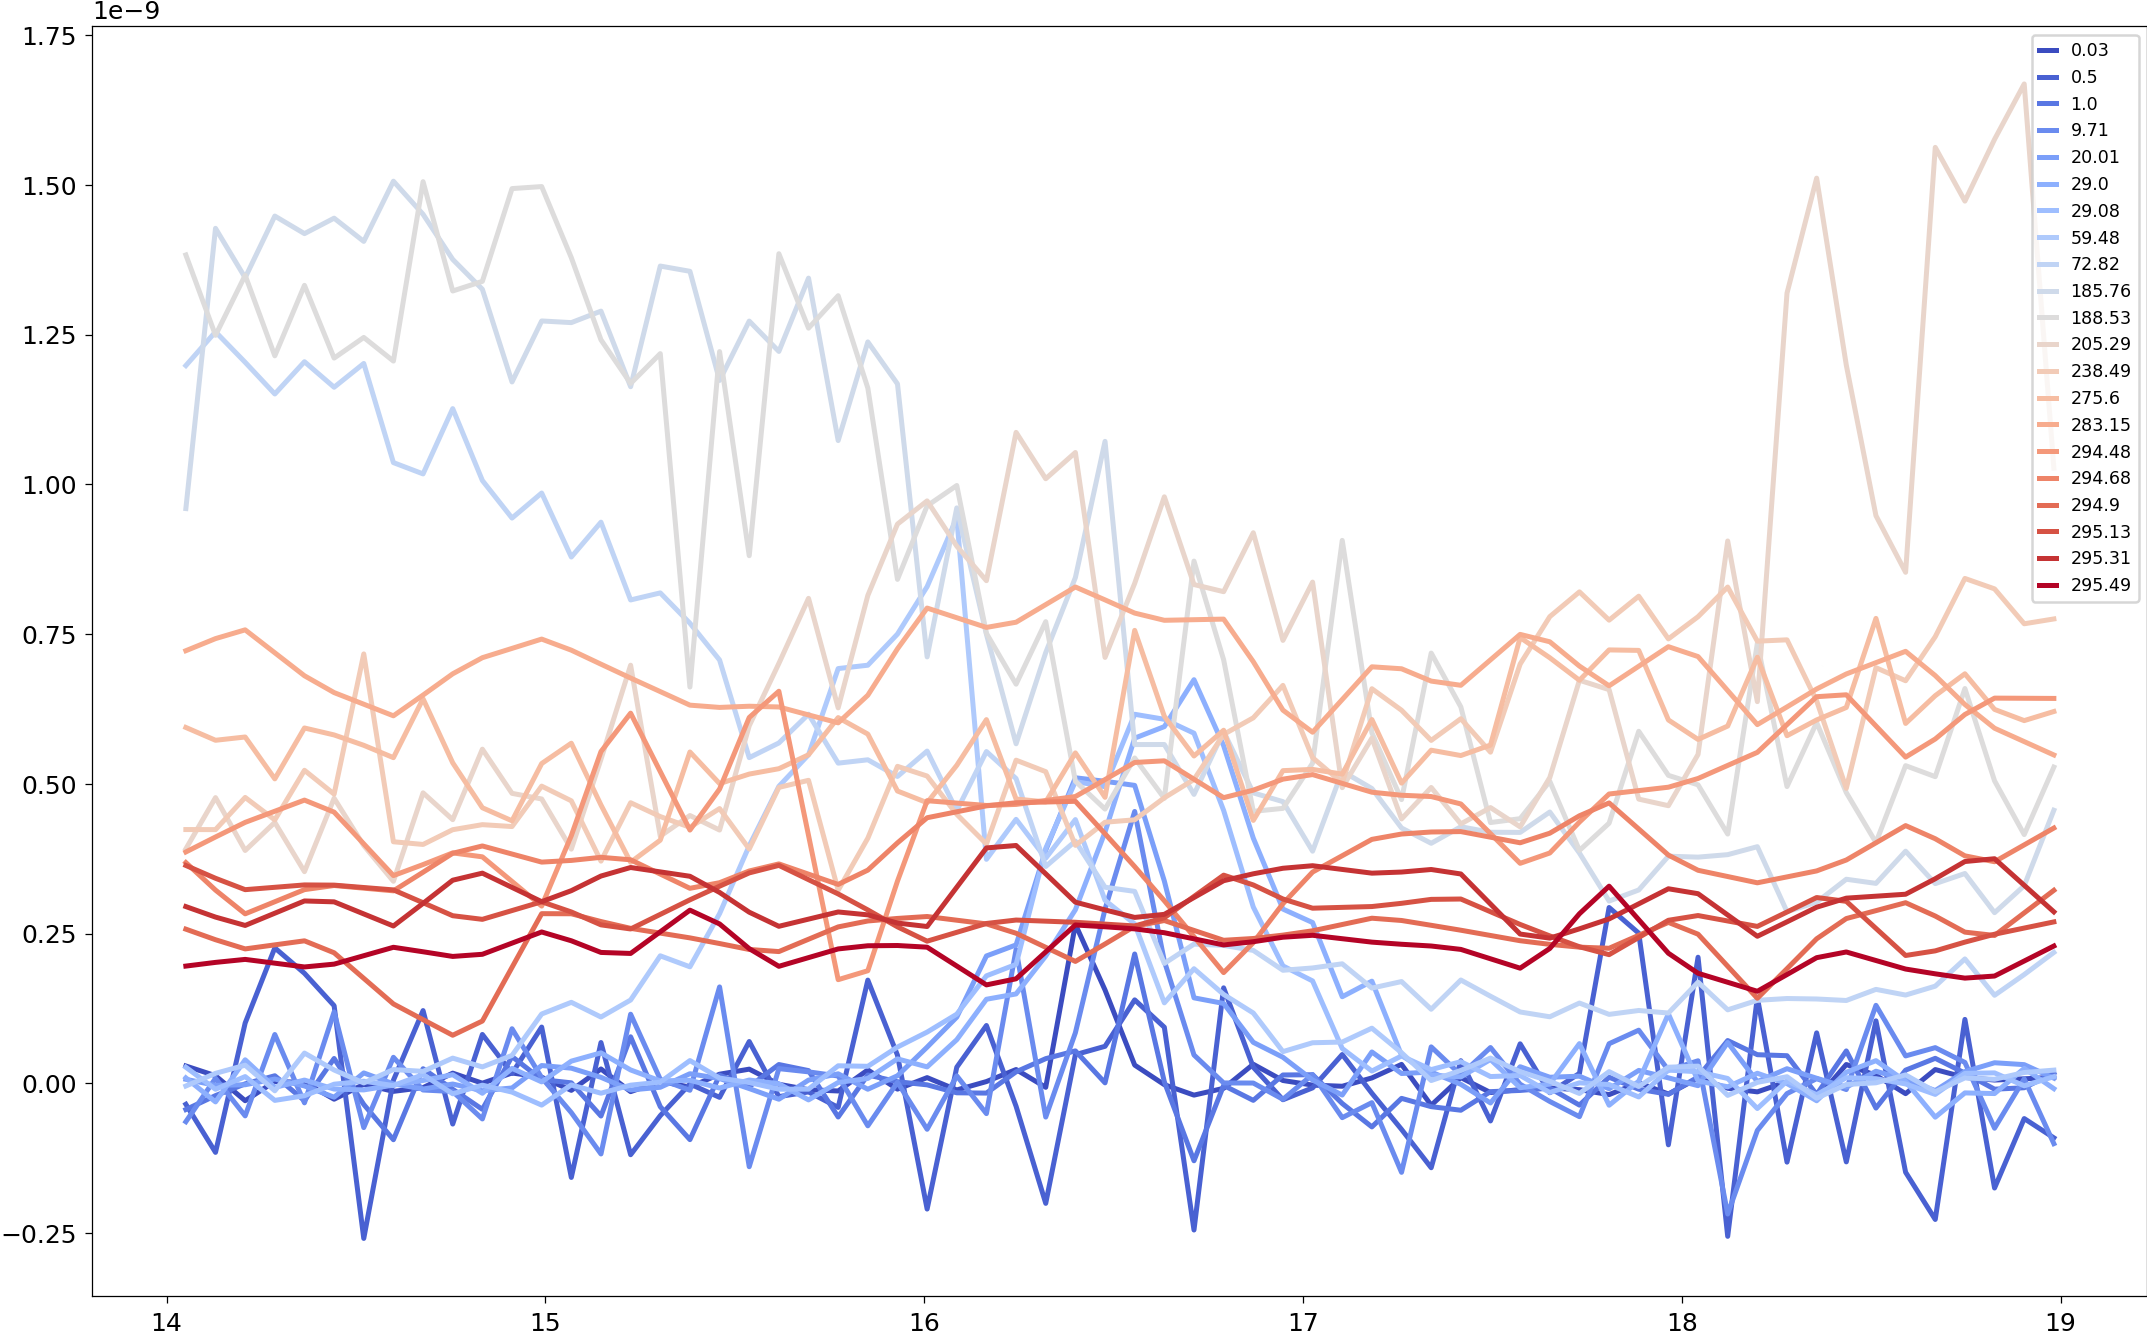

In [194]:
# comment for tomorrow. I think the area should be normalised.
def plot_progr_temp(peak_zbgt, name='progress_temp_pk1_zbgt', save=False):
    fig = plt.figure()
    for i in range(len(peak_zbgt)):
        x = peak_zbgt[i]['Vg']
        y = peak_zbgt[i]['Gsd']
        plt.plot(x, y, color=colors[i], linewidth=2, label=sort_temp[i])
    plt.legend()
    if save == True:
        pf.savefig(fig, fig_dir+name, fmts=['.pdf', '.png'])

for zbgt in all_peaks_zbgt:
    plot_progr_temp(zbgt)

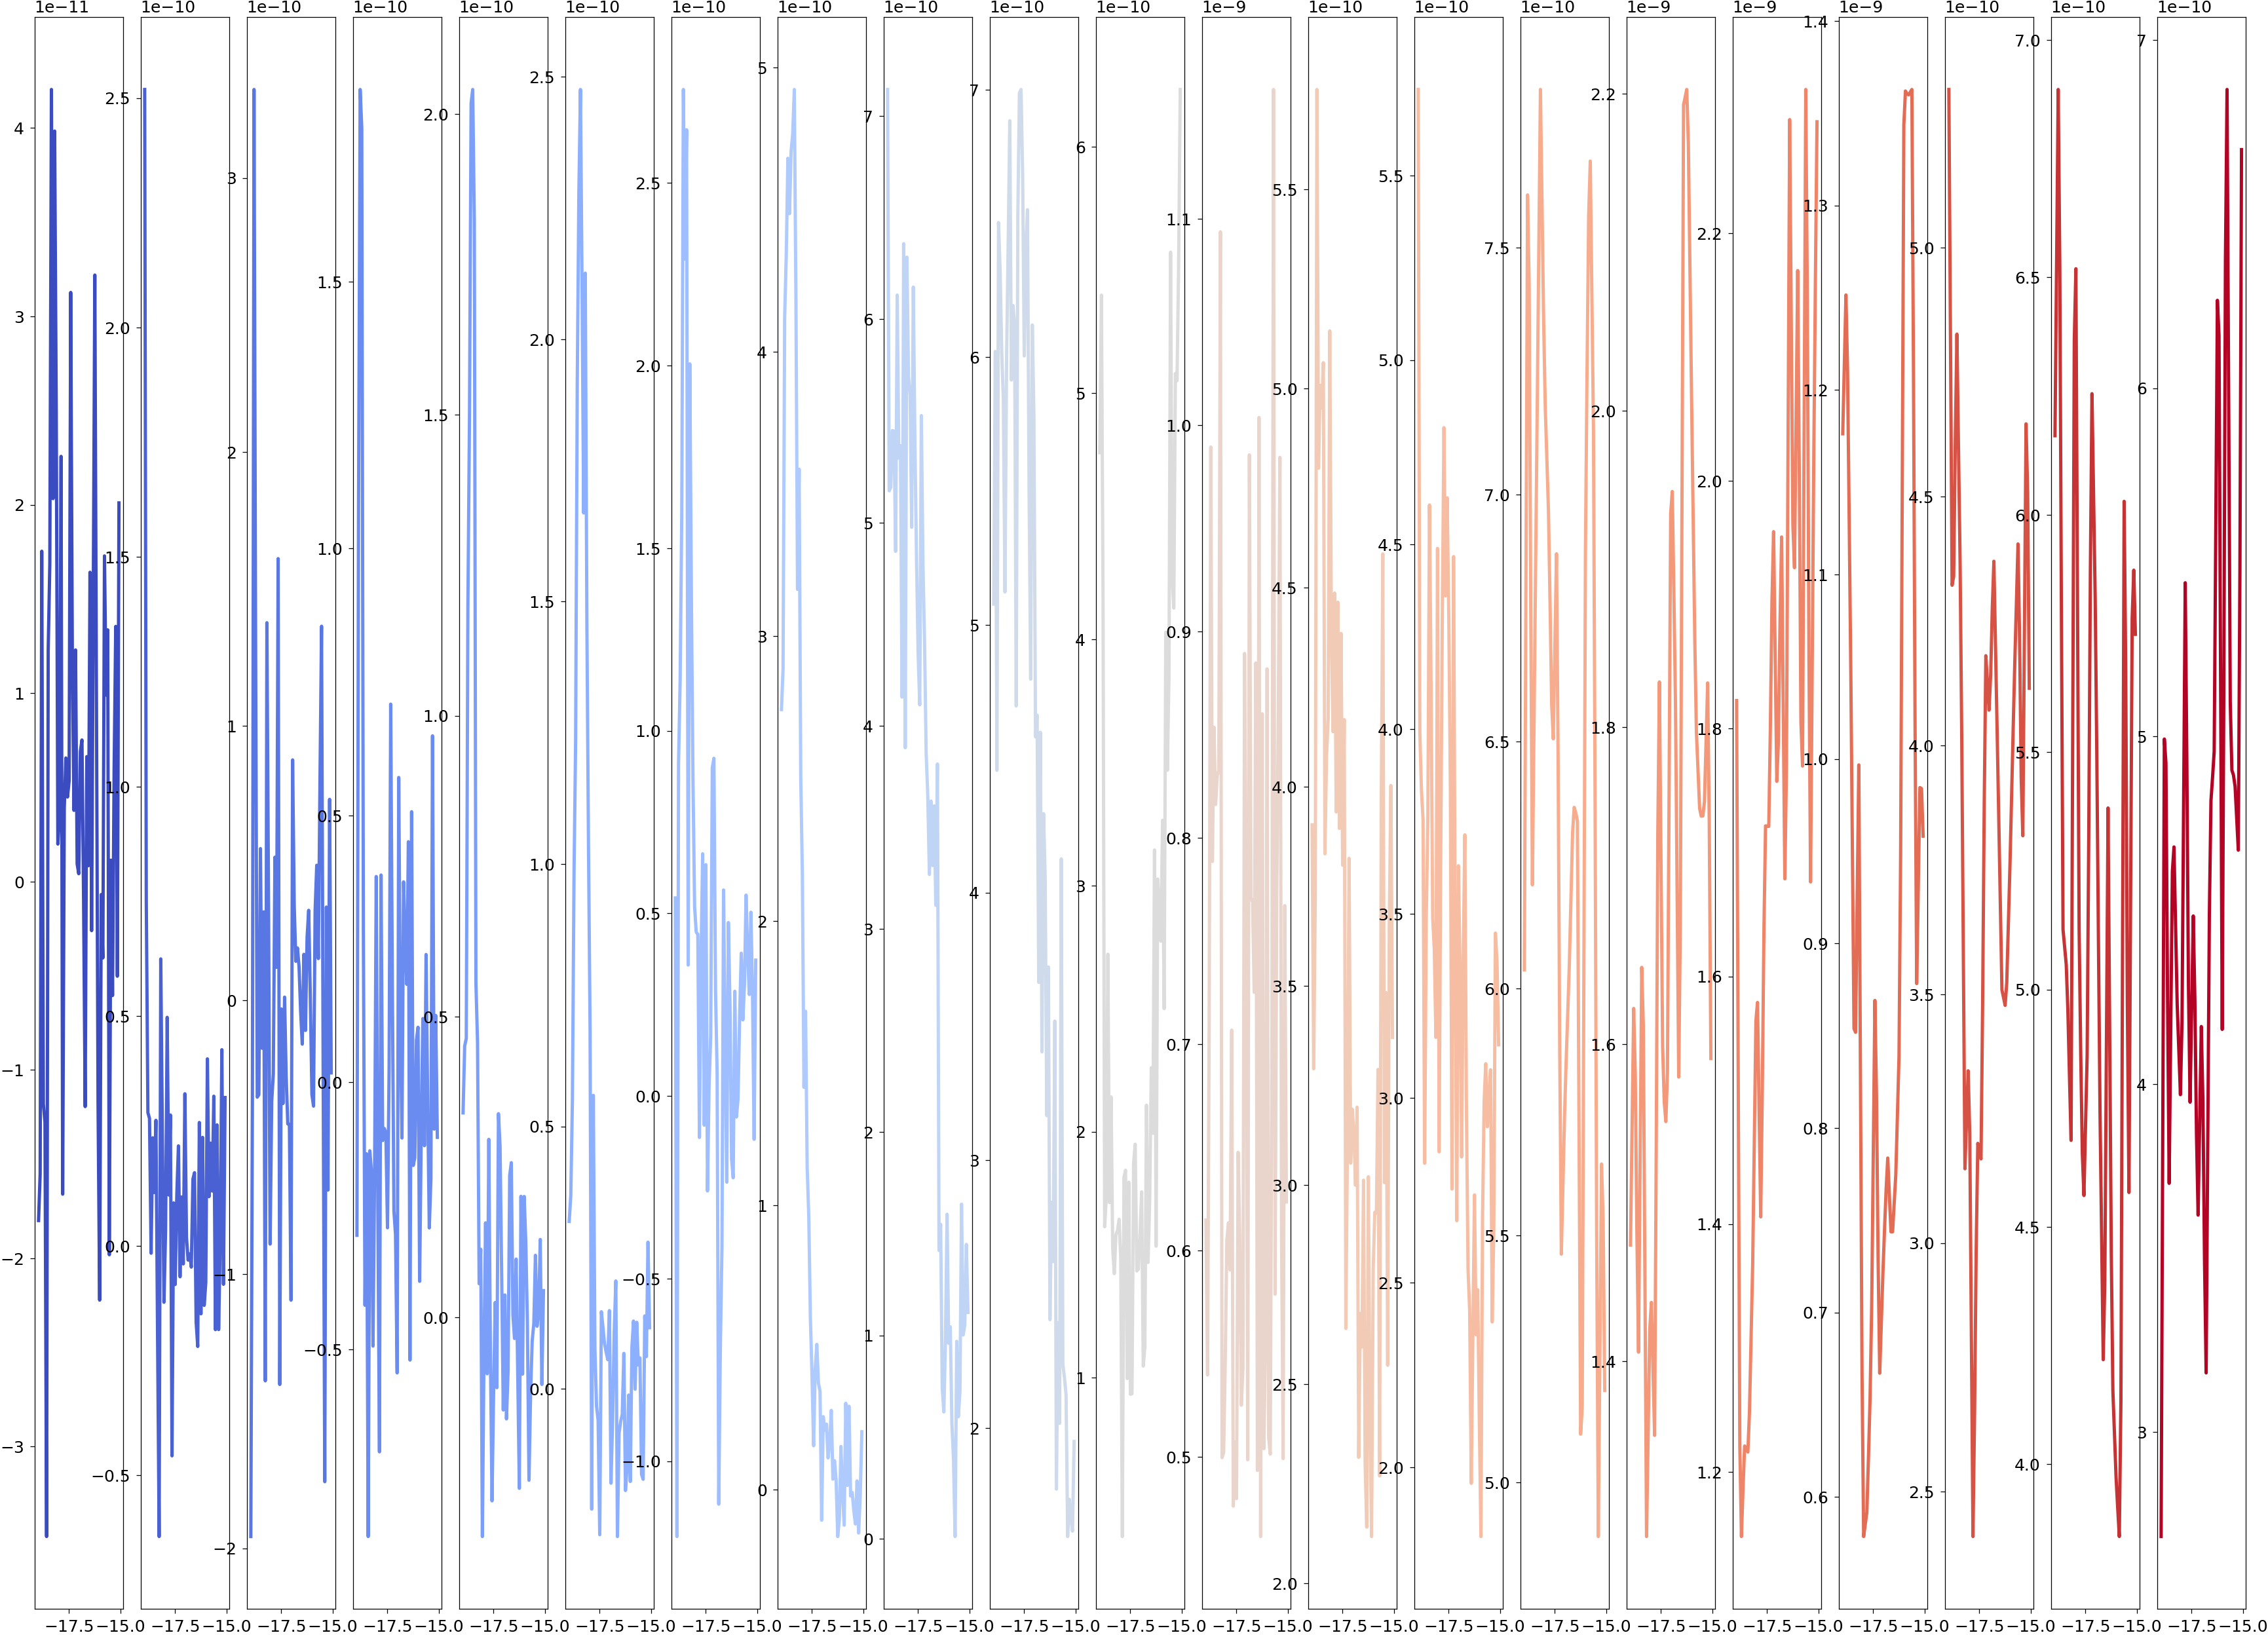

In [167]:
pk1_area = []
fig, axs = plt.subplots(1, len(pk1_zbgt), figsize=(25, 18))

for i, ax in enumerate(axs):
    x = pk1_zbgt[i]['Vg']
    y = pk1_zbgt[i]['Gsd']
    x_integ = np.sort(x, kind='mergesort')
    pk1_area.append(np.trapz(y, x_integ))
    ax.plot(x, y, color=colors[i], linewidth=2)

def integrated_conductance(peak_zbgt):
    peak_area = []
    for i,_ in enumerate(peak_zbgt):
        x = peak_zbgt[i]['Vg']
        y = peak_zbgt[i]['Gsd'] * 1e12
        x_integ = np.sort(x, kind='mergesort')
        peak_area.append(np.trapz(y, x_integ))
    return np.array(peak_area)
pf.savefig(fig,fig_dir+'/prog_temp_pk1_zbgt', fmts=['.png', '.pdf'])

C:\Users\oums1095\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:12: RuntimeWarning: invalid value encountered in log10
  if sys.path[0] == '':


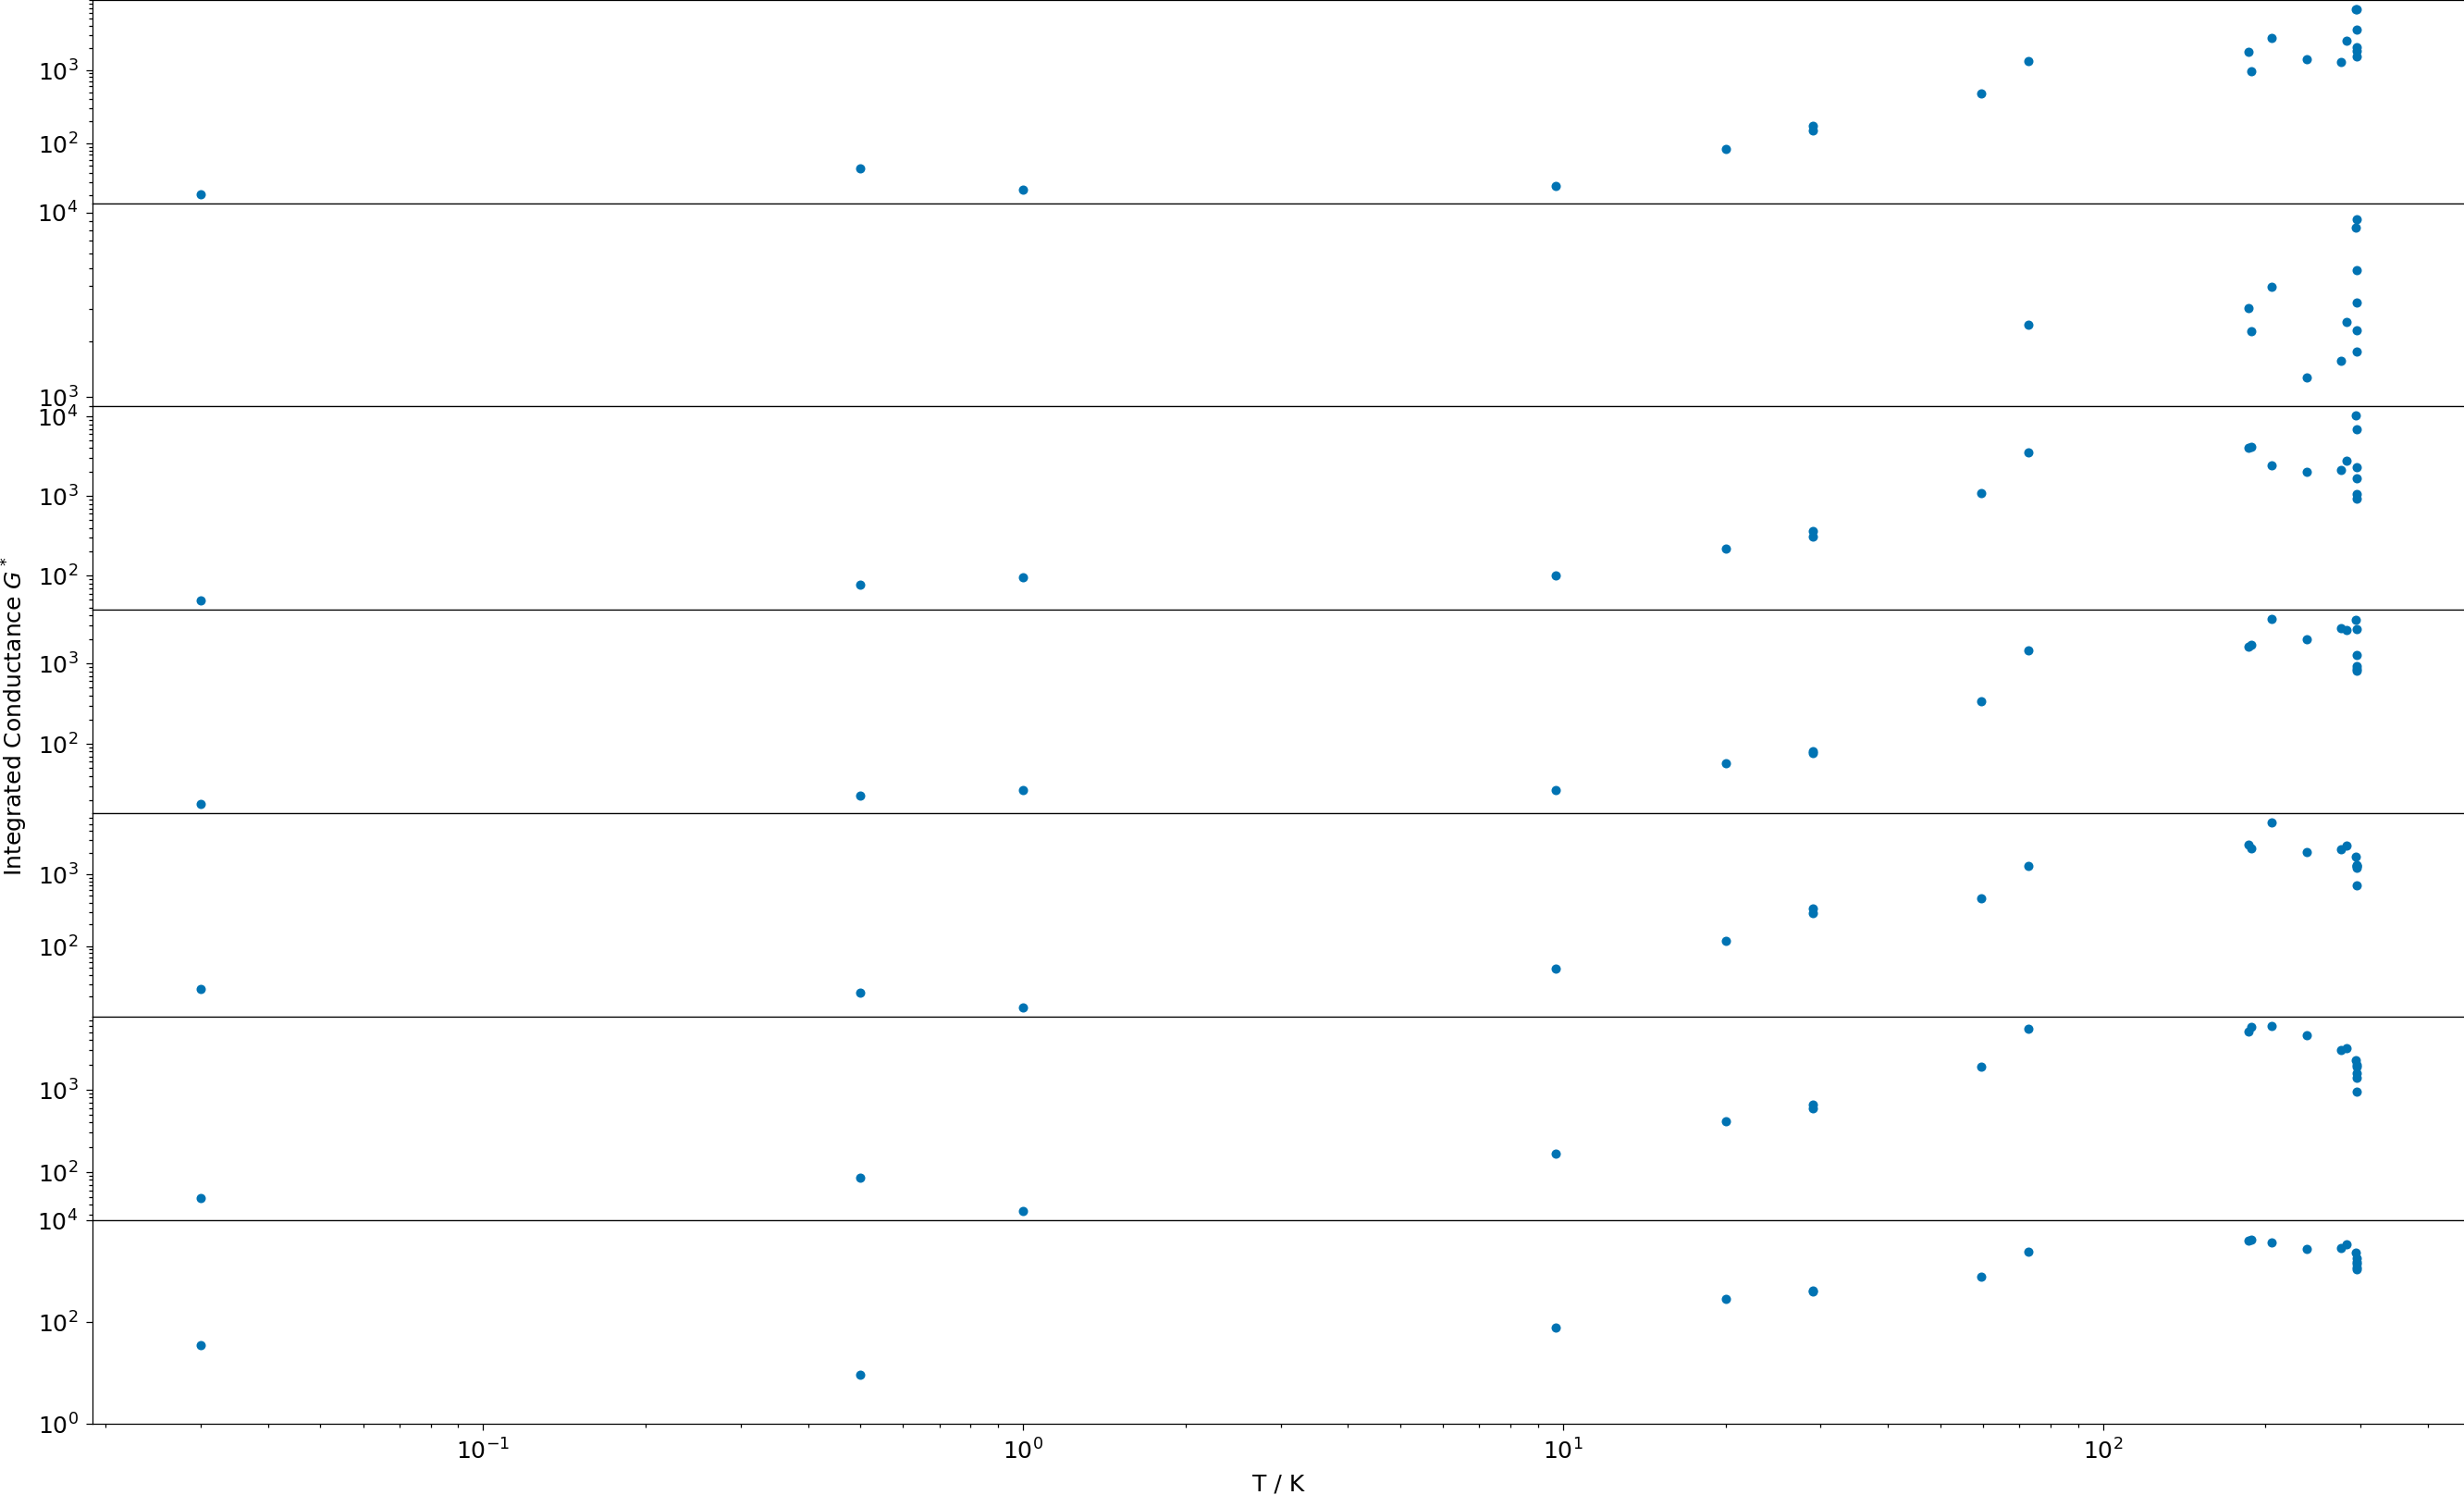

In [133]:
# Plot integrated conductance for all the peaks
fig, axs = plt.subplots(len(all_peaks_zbgt), 1, sharex=True, sharey=False, figsize=(15, 9.4), gridspec_kw={'hspace': 0})
pk_area_dct = {}
pk_area_dct.update({'temp_K': np.array(sort_temp)})
pk_area_dct.update({'log10_temp': np.log10(np.array(sort_temp))})
for i,pk_zbgt in enumerate(all_peaks_zbgt):
    peak_area = integrated_conductance(pk_zbgt) 
    axs[i].scatter(np.array(sort_temp), np.array(peak_area))
    axs[i].set_xscale('log')
    axs[i].set_yscale('log')
    pk_area_dct.update({f'peak{i+1}': peak_area})
    pk_area_dct.update({f'log10_peak{i+1}': np.log10(peak_area)})

# Save dataframe and csv file
pk_area_df = pd.DataFrame(pk_area_dct)
pk_area_df.to_csv('peaks_area_temp.csv')
plt.ylim(1, 1_0000)
plt.xlabel('T / K')
fig.text(0.005, 0.52, 'Integrated Conductance $G^*$', ha='center', va='center', rotation='vertical', fontsize=10)
fig.tight_layout()

In [134]:
pk_area_df

,temp_K,log10_temp,peak1,log10_peak1,peak2,log10_peak2,peak3,log10_peak3,peak4,log10_peak4,peak5,log10_peak5,peak6,log10_peak6,peak7,log10_peak7
0,0.03,-1.522879,20.629330,1.314485,43.544128,1.638930,48.662327,1.687193,17.794775,1.250292,25.885532,1.413057,47.999773,1.681239,35.751536,1.553295
1,0.50,-0.301030,45.723506,1.660140,37.927109,1.578950,77.650858,1.890146,22.551194,1.353170,22.805729,1.358044,85.512764,1.932031,9.008795,0.954667
2,1.00,0.000000,23.490747,1.370897,48.914771,1.689440,96.292819,1.983594,26.636852,1.425483,14.128836,1.150106,33.474215,1.524710,-9.031598,NaN
3,9.71,0.987219,26.030576,1.415484,43.312383,1.636612,100.022537,2.000098,26.363672,1.421006,49.722617,1.696554,167.765019,2.224701,78.484145,1.894782
4,20.01,1.301247,84.503568,1.926875,-116.788816,NaN,218.934578,2.340314,56.931403,1.755352,118.089809,2.072212,408.066513,2.610731,279.140606,2.445823
5,29.00,1.462398,152.356831,2.182862,234.063823,2.369334,311.214063,2.493059,80.418414,1.905356,332.298988,2.521529,590.871951,2.771493,421.375974,2.624670
6,29.08,1.463594,171.772570,2.234954,292.210619,2.465696,369.661246,2.567804,76.738961,1.885016,289.177765,2.461165,649.899215,2.812846,400.568303,2.602677
7,59.48,1.774371,479.979482,2.681223,846.825435,2.927794,1097.506848,3.040407,342.314597,2.534425,460.529419,2.663257,1912.949076,3.281703,789.653758,2.897437
8,72.82,1.862251,1324.502134,3.122053,2471.171931,3.392903,3562.739475,3.551784,1445.008941,3.159871,1322.125172,3.121273,5486.899551,3.739327,2389.483620,3.378304
9,185.76,2.268952,1763.923919,3.246480,3038.757321,3.482696,4073.927300,3.610013,1615.441207,3.208291,2579.099791,3.411468,5133.873184,3.710445,3949.445353,3.596536


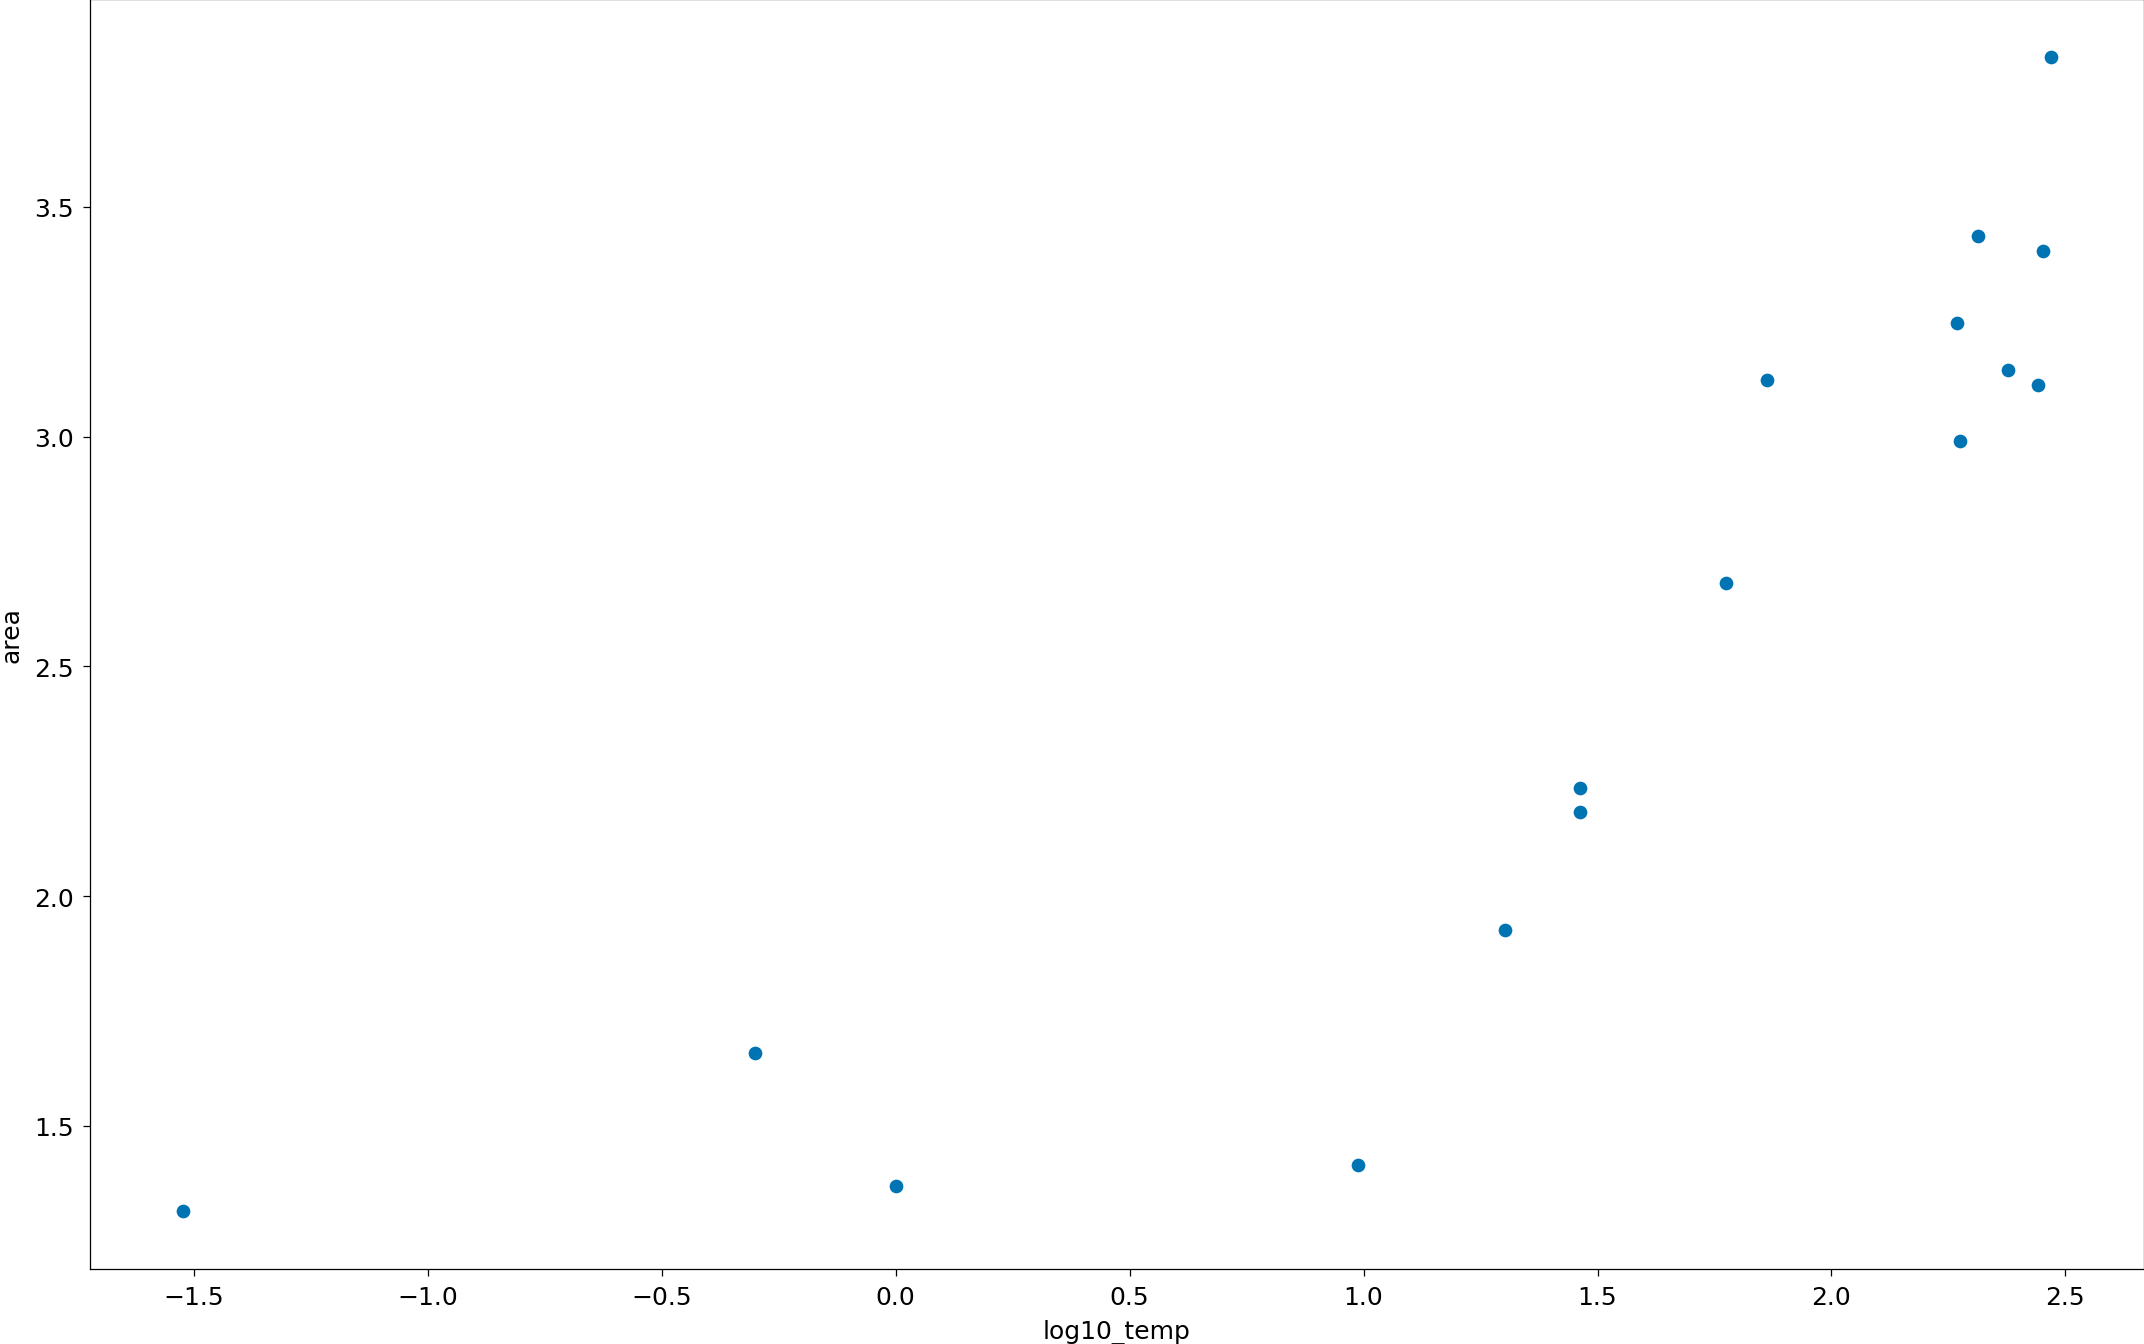

In [141]:
pk_area_melt = pk_area_df.melt(['temp_K', 'log10_temp'], ['log10_peak1','log10_peak2','log10_peak3','log10_peak4','log10_peak5','log10_peak6','log10_peak7'], 'peak', 'area')

def plotarea(df, peak):
    data = df[df.peak == peak]
    data.plot.scatter('log10_temp', 'area')
    
area_melt = pk_area_melt[pk_area_melt.temp_K < 294.5]
plotarea(area_melt, 'log10_peak1')

In [236]:
sort_temp[:-5]

[0.03,
 0.5,
 1.0,
 9.71,
 20.01,
 29.0,
 29.08,
 59.48,
 72.82,
 185.76,
 188.53,
 205.29,
 238.49,
 275.6,
 283.15,
 294.48]

In [238]:
data = pd.DataFrame({'log10_temp': np.log10(np.array(sort_temp[:-5]))}) # select until 294.48 K, which is the T at which I fit the data up to 
# make a xlsx file with context manager
with pd.ExcelWriter('zbgt_fit_result.xlsx') as writer1:
    for peak in range(len(all_peaks_zbgt)):
        data.to_excel(writer1, f'pk{peak+1}_thermalFit', index=False)
        data.to_excel(writer1, f'pk{peak+1}_vgtFit', index=False)

## Plot Single Dataset

In [5]:
fig = Figure()
# fig.add_subplot(Subplot_IVsVg(sd, title=f"sd_{round(T,2)}_K", cmap='plasma')) # plot SD
fig.add_subplot(Subplot_GVg(gt1mv, title=f"gt_{round(T,2)}_K", cmap="plasma"))
fig.add_subplot(Subplot_GVsVg(sd, title=f"sd_{round(T,2)}_K", cmap="plasma")) # plot conductance SD 
fig.add_subplot(Subplot_GVg(zbgt, title=f"zbgt_{round(T,2)}_K", cmap='plasma')) # plot gatetrace
fig.visualise(f'{fig_dir}/sd_gt1mv_{int(T)}_K')

NameError: name 'gt1mv' is not defined

## Manual Fit

In [ ]:
vcs = [-17.97, -12.16, -6.25, -0.81, 3.69, 8.67, 15.05]
# vcs = [-17.97, -12.16, -6.25, -0.81, 3.69, 8.67]
alpha = 0.023 # meV/V
gatetraceFits = []  # an empty list to add the gate trace fits to in the for loop
zbgt_fits = []

In [ ]:
fit_dct_deafult = defaultdict()
lst_temp =  []
lista_param = []

for vc in vcs:  
    dat2 = sd.copy() 
    setdct = {"Vc": vc, "T": T}  
    dat2.ps(**setdct) 
    dat2 = dat2[(dat2["Vg"] > (vc - 2.5)) & (dat2["Vg"] < (vc + 2.5))]  
    gMaxTemp = zbgt["Gsd"].values[(np.argmin(np.abs(zbgt["Vg"].values - vc)))] # We will take this as the initial guess for Gmax for the fitting
    # print("Max Gsd in this window: {:.3e} S".format(gMaxTemp))  # print the Gmax
    p0 = {
        "T": T,
        "Vc": vc,
        "Gmax": gMaxTemp,
        "alpha": alpha
    }  
    # print(f">>> P0 in the script = {p0}")
    bounds = [
        (T - 0.5, vc - 1, 0.3, 0.85 * alpha),
        (T + 0.5, vc + 1, 0.75, 1.15 * alpha)] 
    params, r = dat2.fit_coulomb_peak(bounds=bounds, p0=p0) 
    print(f">>> Opimised Params for peak @ {vc} V: alpha_gate = {params['alpha']:.2f} meV/V, Gmax = {params['Gmax']:.2e} S, Peak position: {params['Vc']:.3f} Vg")  # print the optimised parameters
    params["T"] = T 
    vg = zbgt["Vg"].values  
    fitGsd = physics_models.thermal_broadening(vg, **params)  # use the optimised parameters and the gate voltage array to generate the Gsd fit values. First argument has to be Vg.
    gatetraceFit = zbgt.copy()
    gatetraceFit["Gsd"] = fitGsd
    
    # added these two lines
    lst_temp.append(params['T'])
    lista_param.append(params)
    
    # fit_dct[vc] = params
    
    try:
        # add the fitted gate trace to the list
        gatetraceFits.append(gatetraceFit)
    except:
        pass

## Plot Thermal Fit on top of ZBGT

In [ ]:
gatetraceFitSum = zbgt.copy()
gatetraceFitSum["Gsd"] -= gatetraceFitSum["Gsd"].values  

for fit in gatetraceFits:  
    gatetraceFitSum["Gsd"] += fit["Gsd"].values  

gatetraceFitSum.ps(color="black", label="sum of fits", linewidth=2)  

fig = Figure()
fig.add_subplot(Subplot_GVg(zbgt, title=f"zbgt_{round(T,2)}_K", cmap='plasma')) # plot gatetrace
fig.add_subplot(Subplot_GVg(zbgt, *gatetraceFits, gatetraceFitSum, legend=True))  
fig.visualise(f"{fig_dir}/fit_gatetrace_{int(T)}_K")

 - I want to create a dict of dict
 - the outer keys are the temperature at which GTs were taken
 - the inner keys are the gate voltages for each peaks that I have tried to fit
 - the inner values is the fitting parameters dictionary which holds the optimised fitting parameters

### Load All the Datasets Excluding the 25 and 500 mK Ones

In [ ]:
print(dset)

In [ ]:
dset_refined = dset[:4] + dset[5:] # exclude the very big dataset at 25 mK
print(dset_refined)

### Create a DF and CSV file with All the ZBGT 

In [ ]:
d = {}
for i,dataset in enumerate(dset_refined):
    sd, T = extract_sd_temp(dataset)
    zbgt = extract_zbgt(sd)
    d[T] = zbgt['Gsd']
sorted_d = dict(sorted(d.items()))
df_all_transition = pd.DataFrame(sorted_d, index=zbgt['Vg'])
df_all_transition.to_csv('gate_trace_all_temperature.csv')

### Fit ZBGTs

In [ ]:
zbgt_fits = []
lst_temp =  []
lst_parm = []
for i, dataset in enumerate(dset_refined):
    print(f'Dataset {i}\n')
    sd, T = extract_sd_temp(dataset)
    lst_gate_voltages = lookup_dict_vg_peaks(T)
    gatetraceFits = []  # an empty list to add the gate trace fits to in the for loop
    # zbgt_fits = []
    # lst_temp =  []
    # lst_parm = []
    for vg in lst_gate_voltages:
        fit_zbgt(sd, vg, T)
    gatetraceFitSum = zbgt.copy()
    gatetraceFitSum["Gsd"] -= gatetraceFitSum["Gsd"].values  

    for fit in gatetraceFits:  
        gatetraceFitSum["Gsd"] += fit["Gsd"].values  

    gatetraceFitSum.ps(color="black", label="sum of fits", linewidth=2)  

    fig = Figure()
    fig.add_subplot(Subplot_GVg(extract_zbgt(sd), title=f"zbgt_{round(T,2)}_K", cmap='plasma')) # plot gatetrace
    fig.add_subplot(Subplot_GVg(extract_zbgt(sd), *gatetraceFits, gatetraceFitSum, legend=True))  
    fig.visualise(f"{fig_dir}/test_all/fit_zbgt_{int(T)}_K")